<a href="https://colab.research.google.com/github/Sia0412/Flask-Mega/blob/main/OGA_XAI_HIoT_Colab_asif.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# 0. Optional installation for Google Colab
# ============================================================

import sys, subprocess, importlib, warnings
warnings.filterwarnings("ignore")

def install_if_missing(import_name, pip_name=None):
    pip_name = pip_name or import_name
    try:
        importlib.import_module(import_name)
        print(f"✓ {import_name} already installed")
        return True
    except Exception:
        print(f"Installing {pip_name} ...")
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])
            importlib.import_module(import_name)
            print(f"✓ {pip_name} installed")
            return True
        except Exception as e:
            print(f"⚠ Could not install/use {pip_name}: {e}")
            return False

# Core optional packages for stronger baselines and explainability
HAS_XGBOOST = install_if_missing("xgboost")
HAS_LIGHTGBM = install_if_missing("lightgbm")
HAS_CATBOOST = install_if_missing("catboost")
HAS_SHAP = install_if_missing("shap")

# Optional deep tabular baseline. The proposed OGA model does NOT require these.
HAS_TABNET = install_if_missing("pytorch_tabnet", "pytorch-tabnet")

✓ xgboost already installed
✓ lightgbm already installed
✓ catboost already installed
✓ shap already installed
✓ pytorch_tabnet already installed


In [ ]:
# ============================================================
# 1. Imports, configuration, and reproducibility
# ============================================================
import os, json, math, random, time
from pathlib import Path
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_validate
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, matthews_corrcoef, cohen_kappa_score,
    brier_score_loss
)
from sklearn.inspection import permutation_importance

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier,
    HistGradientBoostingClassifier, StackingClassifier
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

# ------------------------------
# Reproducibility
# ------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# ------------------------------
# Paths
# ------------------------------
OUTPUT_DIR = Path("/content/OGA_XAI_HIoT_outputs") if Path("/content").exists() else Path("/mnt/data/OGA_XAI_HIoT_outputs")
FIG_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
MODEL_DIR = OUTPUT_DIR / "models"
for d in [OUTPUT_DIR, FIG_DIR, TABLE_DIR, MODEL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

DATA_CANDIDATES = [
    "/content/sample_data/digital_ecosystem_smart_healthcare_dataset.csv",
    "/content/primari_dataset_digital_ecosystem_smart_healthcare_dataset.csv",
    "/mnt/data/digital_ecosystem_smart_healthcare_dataset.csv",
    "/mnt/data/primari_dataset_digital_ecosystem_smart_healthcare_dataset.csv",
]

TARGET = "Patient_Health_Status"
CLASS_NAMES = ["Stable", "Moderate_Risk", "High_Risk", "Critical"]
LABEL_TO_ID = {label: i for i, label in enumerate(CLASS_NAMES)}
ID_TO_LABEL = {i: label for label, i in LABEL_TO_ID.items()}
NUM_CLASSES = len(CLASS_NAMES)

# Main settings
TEST_SIZE = 0.20
VAL_SIZE_FROM_REMAINING = 0.20   # gives 64/16/20 train/val/test
N_SPLITS = 5
TUNE_MODELS = True
N_ITER_TUNING = 25
RUN_TABNET_BASELINE = True
RUN_OGA_MULTISEED = True
RUN_SHAP = True

print("Output directory:", OUTPUT_DIR)

Using device: cuda
Output directory: /content/OGA_XAI_HIoT_outputs


In [ ]:
# ============================================================
# 2. Helper functions
# ============================================================

def find_existing_path(candidates):
    for p in candidates:
        if Path(p).exists():
            return Path(p)
    raise FileNotFoundError("Dataset not found. Upload the CSV to /content or update DATA_CANDIDATES.")


def save_csv(df, filename):
    path = TABLE_DIR / filename
    df.to_csv(path, index=False)
    print(f"Saved: {path}")
    return path


def save_fig(filename, dpi=300):
    path = FIG_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Saved figure: {path}")
    plt.show()
    return path


def safe_divide(a, b, eps=1e-8):
    return a / (b + eps)


def multiclass_brier_score(y_true, proba, n_classes=4):
    y_bin = np.zeros((len(y_true), n_classes), dtype=float)
    y_bin[np.arange(len(y_true)), np.asarray(y_true, dtype=int)] = 1.0
    return np.mean(np.sum((proba - y_bin) ** 2, axis=1))


def expected_calibration_error(y_true, proba, n_bins=10):
    confidences = np.max(proba, axis=1)
    predictions = np.argmax(proba, axis=1)
    accuracies = (predictions == np.asarray(y_true)).astype(float)
    ece = 0.0
    for i in range(n_bins):
        low, high = i / n_bins, (i + 1) / n_bins
        mask = (confidences > low) & (confidences <= high)
        if np.any(mask):
            bin_acc = np.mean(accuracies[mask])
            bin_conf = np.mean(confidences[mask])
            ece += np.mean(mask) * abs(bin_acc - bin_conf)
    return ece


def ordinal_error_summary(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    err = np.abs(y_true - y_pred)
    severe = (err >= 2).astype(int)
    return {
        "Mean_Absolute_Ordinal_Error": float(np.mean(err)),
        "Median_Absolute_Ordinal_Error": float(np.median(err)),
        "Severe_Misclassification_Rate": float(np.mean(severe)),
        "Max_Ordinal_Error": int(np.max(err)),
    }


def compute_metrics(y_true, y_pred, proba=None, prefix=""):
    metrics = {
        f"{prefix}Accuracy": accuracy_score(y_true, y_pred),
        f"{prefix}Balanced_Accuracy": balanced_accuracy_score(y_true, y_pred),
        f"{prefix}Macro_Precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        f"{prefix}Macro_Recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        f"{prefix}Macro_F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        f"{prefix}Weighted_F1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        f"{prefix}MCC": matthews_corrcoef(y_true, y_pred),
        f"{prefix}Cohen_Kappa": cohen_kappa_score(y_true, y_pred),
    }
    metrics.update({f"{prefix}{k}": v for k, v in ordinal_error_summary(y_true, y_pred).items()})
    if proba is not None:
        try:
            metrics[f"{prefix}Multiclass_ROC_AUC_OVR"] = roc_auc_score(y_true, proba, multi_class="ovr", average="macro")
        except Exception:
            metrics[f"{prefix}Multiclass_ROC_AUC_OVR"] = np.nan
        metrics[f"{prefix}Multiclass_Brier"] = multiclass_brier_score(y_true, proba, NUM_CLASSES)
        metrics[f"{prefix}ECE"] = expected_calibration_error(y_true, proba)
    return metrics


def print_report(y_true, y_pred, title="Classification Report"):
    print("=" * 80)
    print(title)
    print("=" * 80)
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))


def plot_confusion_matrix(y_true, y_pred, title, filename):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(NUM_CLASSES)
    plt.xticks(tick_marks, CLASS_NAMES, rotation=25, ha="right")
    plt.yticks(tick_marks, CLASS_NAMES)
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], "d"), ha="center", va="center")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    save_fig(filename)
    return cm

Loading dataset from: /content/sample_data/digital_ecosystem_smart_healthcare_dataset.csv
Dataset shape: (4000, 18)


,Heart_Rate,Blood_Pressure,Blood_Oxygen_Level,Body_Temperature,Respiration_Rate,Glucose_Level,ECG_Signal_Intensity,Activity_Level,Sleep_Duration_Hours,Stress_Index,IoT_Device_Connectivity,EHR_Data_Completeness,Wearable_Device_Count,Daily_Steps,Healthcare_Network_Latency_ms,Cloud_Data_Transfer_Rate,Medical_Alert_Frequency,Patient_Health_Status
0,45,166,100.00,35.15,8,114,3.648,0,6.80,76,100,50,4,13855,247,93.53,8,Stable
1,74,122,100.00,36.99,8,136,2.223,53,2.22,26,74,45,5,3817,13,91.79,6,High_Risk
2,76,200,100.00,34.00,17,94,1.383,10,7.34,22,78,38,3,5458,194,54.91,1,Stable
3,56,81,94.05,38.45,21,60,1.498,37,10.08,74,100,85,5,6307,98,73.87,2,Moderate_Risk
4,109,200,96.85,36.63,17,157,0.500,0,9.61,0,25,100,5,9933,153,46.42,3,Moderate_Risk


Saved: /content/OGA_XAI_HIoT_outputs/tables/01_dataset_profile.csv
Duplicate rows: 0
Saved: /content/OGA_XAI_HIoT_outputs/tables/02_class_distribution.csv


,Class,Count,Percent
0,Stable,999,24.975
1,Moderate_Risk,1001,25.025
2,High_Risk,997,24.925
3,Critical,1003,25.075


Saved: /content/OGA_XAI_HIoT_outputs/tables/01b_descriptive_statistics.csv
Saved figure: /content/OGA_XAI_HIoT_outputs/figures/Figure_1_Class_Distribution.png


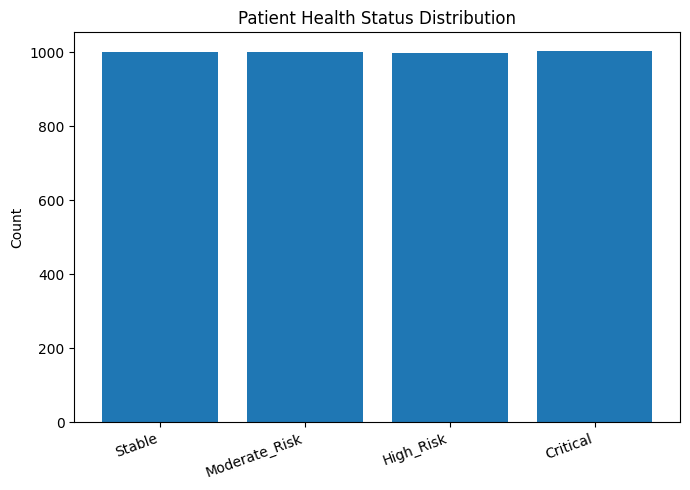

PosixPath('/content/OGA_XAI_HIoT_outputs/figures/Figure_1_Class_Distribution.png')

In [ ]:
# ============================================================
# 3. Load dataset and initial profiling
# ============================================================
DATA_PATH = find_existing_path(DATA_CANDIDATES)
print("Loading dataset from:", DATA_PATH)

df_raw = pd.read_csv(DATA_PATH)
print("Dataset shape:", df_raw.shape)
display(df_raw.head())

required_columns = [
    "Heart_Rate", "Blood_Pressure", "Blood_Oxygen_Level", "Body_Temperature",
    "Respiration_Rate", "Glucose_Level", "ECG_Signal_Intensity",
    "Activity_Level", "Sleep_Duration_Hours", "Stress_Index", "Daily_Steps",
    "IoT_Device_Connectivity", "EHR_Data_Completeness", "Wearable_Device_Count",
    "Healthcare_Network_Latency_ms", "Cloud_Data_Transfer_Rate",
    "Medical_Alert_Frequency", TARGET
]

missing_required = [c for c in required_columns if c not in df_raw.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

profile = pd.DataFrame({
    "Column": df_raw.columns,
    "Dtype": [str(df_raw[c].dtype) for c in df_raw.columns],
    "Missing_Count": [df_raw[c].isna().sum() for c in df_raw.columns],
    "Missing_Percent": [df_raw[c].isna().mean() * 100 for c in df_raw.columns],
    "Unique_Count": [df_raw[c].nunique() for c in df_raw.columns],
})
save_csv(profile, "01_dataset_profile.csv")

duplicate_count = int(df_raw.duplicated().sum())
print("Duplicate rows:", duplicate_count)

class_dist = df_raw[TARGET].value_counts().reindex(CLASS_NAMES)
class_percent = df_raw[TARGET].value_counts(normalize=True).reindex(CLASS_NAMES) * 100
class_table = pd.DataFrame({"Class": CLASS_NAMES, "Count": class_dist.values, "Percent": class_percent.values})
save_csv(class_table, "02_class_distribution.csv")
display(class_table)

desc = df_raw.drop(columns=[TARGET]).describe().T.reset_index().rename(columns={"index": "Feature"})
save_csv(desc, "01b_descriptive_statistics.csv")

plt.figure(figsize=(7, 5))
plt.bar(class_table["Class"], class_table["Count"])
plt.title("Patient Health Status Distribution")
plt.ylabel("Count")
plt.xticks(rotation=20, ha="right")
save_fig("Figure_1_Class_Distribution.png")

In [ ]:
# ============================================================
# 4. Target encoding and leakage audit
# ============================================================
df = df_raw.copy()

invalid_labels = sorted(set(df[TARGET].unique()) - set(CLASS_NAMES))
if invalid_labels:
    raise ValueError(f"Unexpected target labels found: {invalid_labels}")

df["Patient_Health_Status_Label"] = df[TARGET]
df[TARGET] = df[TARGET].map(LABEL_TO_ID).astype(int)

print(df[["Patient_Health_Status_Label", TARGET]].head())
print(df[TARGET].value_counts().sort_index())

# Leakage audit: no target-like columns are allowed inside X.
leakage_keywords = ["status", "target", "risk", "label", "class", "outcome"]
feature_candidates = [c for c in df.columns if c not in [TARGET, "Patient_Health_Status_Label"]]
suspected = []
for col in feature_candidates:
    lc = col.lower()
    if any(k in lc for k in leakage_keywords):
        suspected.append(col)

leakage_report = pd.DataFrame({
    "Check": ["Duplicate Rows", "Suspicious Feature Names", "Target In Features"],
    "Result": [duplicate_count, ", ".join(suspected) if suspected else "None", TARGET in feature_candidates]
})
save_csv(leakage_report, "02b_leakage_audit.csv")
display(leakage_report)

if suspected:
    print("⚠ Review suspected features before modeling:", suspected)
else:
    print("✓ No target-derived feature names detected.")

  Patient_Health_Status_Label  Patient_Health_Status
0                      Stable                      0
1                   High_Risk                      2
2                      Stable                      0
3               Moderate_Risk                      1
4               Moderate_Risk                      1
Patient_Health_Status
0     999
1    1001
2     997
3    1003
Name: count, dtype: int64
Saved: /content/OGA_XAI_HIoT_outputs/tables/02b_leakage_audit.csv


,Check,Result
0,Duplicate Rows,0
1,Suspicious Feature Names,None
2,Target In Features,False


✓ No target-derived feature names detected.


In [ ]:
# ============================================================
# 5. Feature engineering aligned with the proposal
# ============================================================
df_fe = df.copy()
EPS = 1e-8

# Physiological derived features
df_fe["HR_BP_Interaction"] = df_fe["Heart_Rate"] * df_fe["Blood_Pressure"]
df_fe["Oxygen_Respiration_Ratio"] = safe_divide(df_fe["Blood_Oxygen_Level"], df_fe["Respiration_Rate"], EPS)
df_fe["Glucose_Stress_Interaction"] = df_fe["Glucose_Level"] * df_fe["Stress_Index"]
df_fe["ECG_HR_Interaction"] = df_fe["ECG_Signal_Intensity"] * df_fe["Heart_Rate"]

# Behavioral derived features
df_fe["Activity_Sleep_Ratio"] = safe_divide(df_fe["Activity_Level"], df_fe["Sleep_Duration_Hours"], EPS)
df_fe["Steps_per_Activity"] = safe_divide(df_fe["Daily_Steps"], df_fe["Activity_Level"], EPS)
df_fe["Stress_Sleep_Ratio"] = safe_divide(df_fe["Stress_Index"], df_fe["Sleep_Duration_Hours"], EPS)

# IoT/data-quality derived features
df_fe["Connectivity_EHR_Product"] = df_fe["IoT_Device_Connectivity"] * df_fe["EHR_Data_Completeness"]
df_fe["Wearable_Connectivity_Ratio"] = safe_divide(df_fe["Wearable_Device_Count"], df_fe["IoT_Device_Connectivity"], EPS)

# Network/cloud derived features
df_fe["Latency_Transfer_Ratio"] = safe_divide(df_fe["Healthcare_Network_Latency_ms"], df_fe["Cloud_Data_Transfer_Rate"], EPS)
df_fe["Network_Load_Index"] = df_fe["Healthcare_Network_Latency_ms"] * df_fe["Medical_Alert_Frequency"]

# Replace infinite values if any numerical instability occurs
num_cols_fe = df_fe.select_dtypes(include=[np.number]).columns
df_fe[num_cols_fe] = df_fe[num_cols_fe].replace([np.inf, -np.inf], np.nan)

engineered_features = [c for c in df_fe.columns if c not in df.columns]
print("Engineered features:", engineered_features)
display(df_fe[engineered_features].head())

save_csv(df_fe, "feature_engineered_primary_dataset.csv")

Engineered features: ['HR_BP_Interaction', 'Oxygen_Respiration_Ratio', 'Glucose_Stress_Interaction', 'ECG_HR_Interaction', 'Activity_Sleep_Ratio', 'Steps_per_Activity', 'Stress_Sleep_Ratio', 'Connectivity_EHR_Product', 'Wearable_Connectivity_Ratio', 'Latency_Transfer_Ratio', 'Network_Load_Index']


,HR_BP_Interaction,Oxygen_Respiration_Ratio,Glucose_Stress_Interaction,ECG_HR_Interaction,Activity_Sleep_Ratio,Steps_per_Activity,Stress_Sleep_Ratio,Connectivity_EHR_Product,Wearable_Connectivity_Ratio,Latency_Transfer_Ratio,Network_Load_Index
0,7470,12.500000,8664,164.160,0.000000,1.385500e+12,11.176471,5000,0.040000,2.640864,1976
1,9028,12.500000,3536,164.502,23.873874,7.201887e+01,11.711712,3330,0.067568,0.141628,78
2,15200,5.882353,2068,105.108,1.362398,5.458000e+02,2.997275,2964,0.038462,3.533054,194
3,4536,4.478571,4440,83.888,3.670635,1.704595e+02,7.341270,8500,0.050000,1.326655,196
4,21800,5.697059,0,54.500,0.000000,9.933000e+11,0.000000,2500,0.200000,3.295993,459


Saved: /content/OGA_XAI_HIoT_outputs/tables/feature_engineered_primary_dataset.csv


PosixPath('/content/OGA_XAI_HIoT_outputs/tables/feature_engineered_primary_dataset.csv')

In [ ]:
# ============================================================
# 6. Feature groups for OGA-XAI-HIoT
# ============================================================
FEATURE_GROUPS = {
    "Physiological": [
        "Heart_Rate", "Blood_Pressure", "Blood_Oxygen_Level", "Body_Temperature",
        "Respiration_Rate", "Glucose_Level", "ECG_Signal_Intensity",
        "HR_BP_Interaction", "Oxygen_Respiration_Ratio", "Glucose_Stress_Interaction",
        "ECG_HR_Interaction"
    ],
    "Behavioral": [
        "Activity_Level", "Sleep_Duration_Hours", "Stress_Index", "Daily_Steps",
        "Activity_Sleep_Ratio", "Steps_per_Activity", "Stress_Sleep_Ratio"
    ],
    "IoT_Data_Quality": [
        "IoT_Device_Connectivity", "EHR_Data_Completeness", "Wearable_Device_Count",
        "Connectivity_EHR_Product", "Wearable_Connectivity_Ratio"
    ],
    "Network_Cloud": [
        "Healthcare_Network_Latency_ms", "Cloud_Data_Transfer_Rate",
        "Latency_Transfer_Ratio", "Network_Load_Index"
    ],
    "Alert": ["Medical_Alert_Frequency"]
}

# Keep only available columns.
for group, feats in list(FEATURE_GROUPS.items()):
    FEATURE_GROUPS[group] = [f for f in feats if f in df_fe.columns]

print(json.dumps(FEATURE_GROUPS, indent=2))

feature_group_table = []
for group, feats in FEATURE_GROUPS.items():
    for f in feats:
        feature_group_table.append({"Group": group, "Feature": f})
save_csv(pd.DataFrame(feature_group_table), "02c_feature_group_definition.csv")

{
  "Physiological": [
    "Heart_Rate",
    "Blood_Pressure",
    "Blood_Oxygen_Level",
    "Body_Temperature",
    "Respiration_Rate",
    "Glucose_Level",
    "ECG_Signal_Intensity",
    "HR_BP_Interaction",
    "Oxygen_Respiration_Ratio",
    "Glucose_Stress_Interaction",
    "ECG_HR_Interaction"
  ],
  "Behavioral": [
    "Activity_Level",
    "Sleep_Duration_Hours",
    "Stress_Index",
    "Daily_Steps",
    "Activity_Sleep_Ratio",
    "Steps_per_Activity",
    "Stress_Sleep_Ratio"
  ],
  "IoT_Data_Quality": [
    "IoT_Device_Connectivity",
    "EHR_Data_Completeness",
    "Wearable_Device_Count",
    "Connectivity_EHR_Product",
    "Wearable_Connectivity_Ratio"
  ],
  "Network_Cloud": [
    "Healthcare_Network_Latency_ms",
    "Cloud_Data_Transfer_Rate",
    "Latency_Transfer_Ratio",
    "Network_Load_Index"
  ],
  "Alert": [
    "Medical_Alert_Frequency"
  ]
}
Saved: /content/OGA_XAI_HIoT_outputs/tables/02c_feature_group_definition.csv


PosixPath('/content/OGA_XAI_HIoT_outputs/tables/02c_feature_group_definition.csv')

Saved: /content/OGA_XAI_HIoT_outputs/tables/03_high_low_consistency_analysis.csv


,Feature,Mean,Std,Minimum,Maximum,Median,IQR,Coefficient_of_Variation,Skewness,Outlier_Percentage,Consistency
22,Steps_per_Activity,1.249719e+11,3.698707e+11,10.180000,1.798800e+12,192.058608,389.489682,2.959631,3.052408,17.375,Highly Variable
26,Latency_Transfer_Ratio,3.920307e+00,5.061374e+00,0.052154,4.675835e+01,2.373835,3.078891,1.291066,3.476254,10.000,Highly Variable
21,Activity_Sleep_Ratio,9.019705e+00,8.988270e+00,0.000000,5.000000e+01,7.000000,9.366169,0.996515,1.913544,5.325,Highly Variable
27,Network_Load_Index,8.797057e+02,8.077891e+02,0.000000,3.486000e+03,640.000000,1120.500000,0.918249,1.008756,1.350,Highly Variable
19,Glucose_Stress_Interaction,5.297984e+03,4.686168e+03,0.000000,3.000000e+04,4354.000000,5760.000000,0.884519,1.285272,3.400,Highly Variable
25,Wearable_Connectivity_Ratio,4.964879e-02,4.272878e-02,0.010000,2.500000e-01,0.040000,0.034674,0.860621,2.406833,7.775,Highly Variable
23,Stress_Sleep_Ratio,7.912283e+00,6.769957e+00,0.000000,5.000000e+01,7.129997,7.621045,0.855626,1.765260,3.675,Highly Variable
9,Stress_Index,5.017125e+01,3.423743e+01,0.000000,1.000000e+02,50.000000,60.000000,0.682411,0.028423,0.000,Highly Variable
7,Activity_Level,4.936675e+01,3.348304e+01,0.000000,1.000000e+02,50.000000,57.000000,0.678251,0.010389,0.000,Highly Variable
20,ECG_HR_Interaction,1.992726e+02,1.319911e+02,22.500000,7.631660e+02,180.071000,190.614500,0.662364,0.798588,1.100,Highly Variable


Saved figure: /content/OGA_XAI_HIoT_outputs/figures/Figure_2_Feature_Variability.png


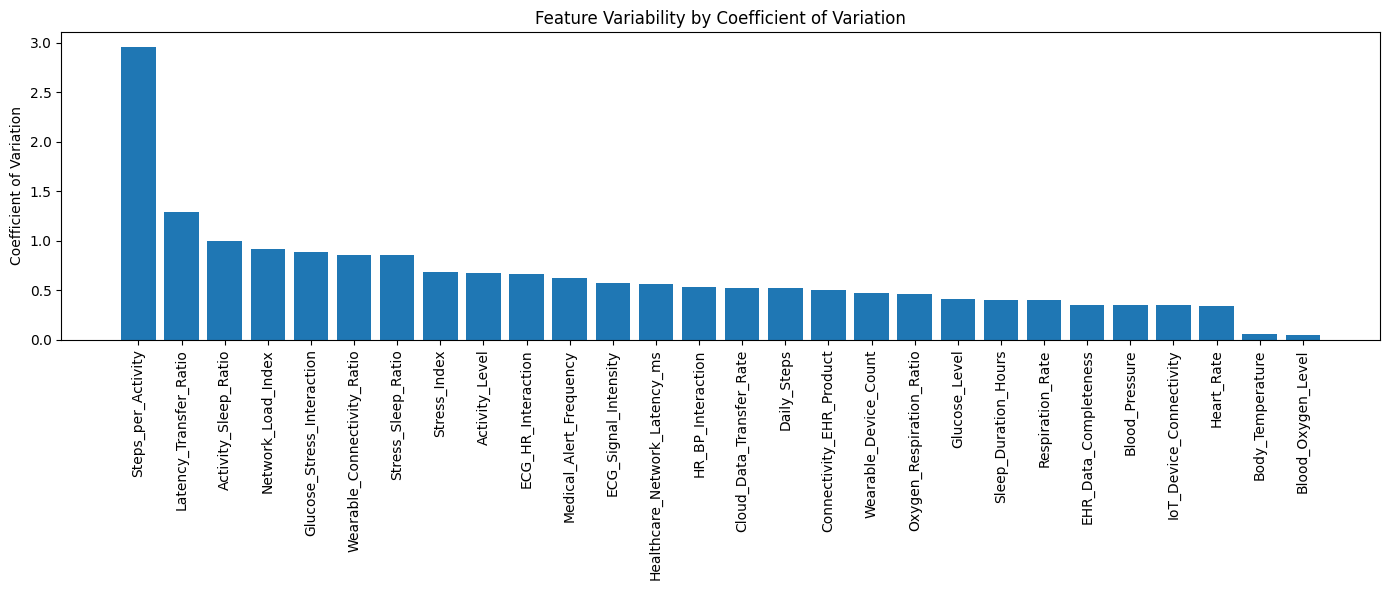

Activity_Level                             \
                                      mean        std median min  max   
Patient_Health_Status_Label                                             
Critical                         52.765703  33.937831   54.0   0  100   
High_Risk                        54.373119  33.959331   58.0   0  100   
Moderate_Risk                    53.430569  32.793344   56.0   0  100   
Stable                           36.885886  29.971680   33.0   0  100   

                             Daily_Steps                                     \
                                    mean          std   median   min    max   
Patient_Health_Status_Label                                                   
Critical                     9401.960120  4953.522565   9488.0  1001  17999   
High_Risk                    9459.398195  5013.877407   9501.0  1018  17999   
Moderate_Risk                9214.855145  4917.474694   8966.0  1028  17980   
Stable                       9935.816817  4839.375256  10088.0  1053  17999   

                            Sleep_Duration_Hours                              \
                                            mean       std median  min   max   
Patient_Health_Status_Label                                                    
Critical                                5.689442  2.595615   5.57  2.0  12.0   
High_Risk                               6.871294  2.681235   6.77  2.0  12.0   
Moderate_Risk                           6.998092  2.866011   7.12  2.0  12.0   
Stable                                  8.341572  2.504935   8.48  2.0  12.0   

                            Stress_Index                             
                                    mean        std median min  max  
Patient_Health_Status_Label                                          
Critical                       38.897308  31.321914   35.0   0  100  
High_Risk                      60.202608  33.492268   65.0   0  100  
Moderate_Risk                  43.475524  33.347438   41.0   0  100  
Stable                         58.188188  33.774251   60.0   0  100

Saved figure: /content/OGA_XAI_HIoT_outputs/figures/Figure_3_Activity_Level_by_Health_Status.png


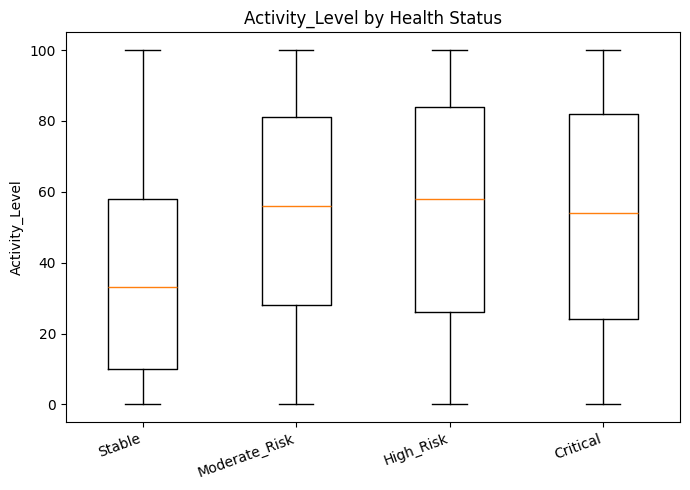

Saved figure: /content/OGA_XAI_HIoT_outputs/figures/Figure_3_Daily_Steps_by_Health_Status.png


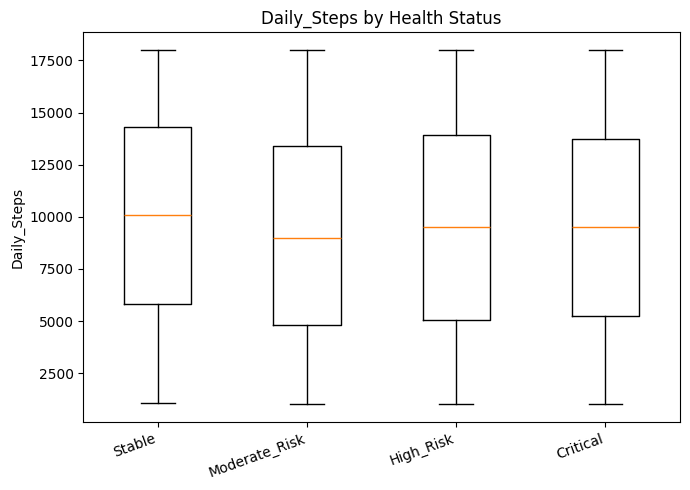

Saved figure: /content/OGA_XAI_HIoT_outputs/figures/Figure_3_Sleep_Duration_Hours_by_Health_Status.png


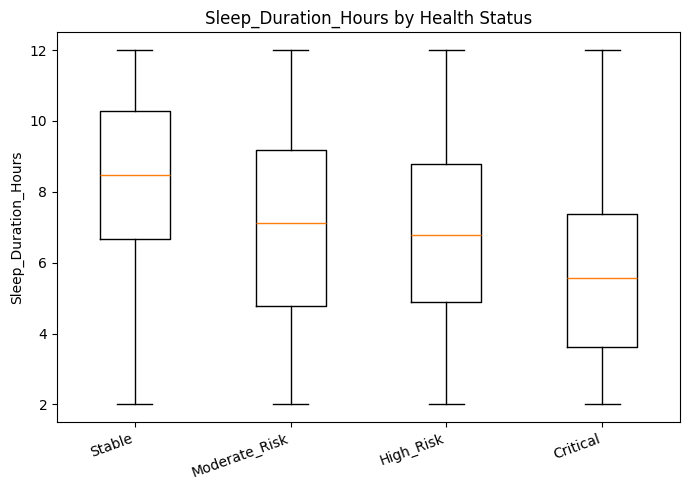

Saved figure: /content/OGA_XAI_HIoT_outputs/figures/Figure_3_Stress_Index_by_Health_Status.png


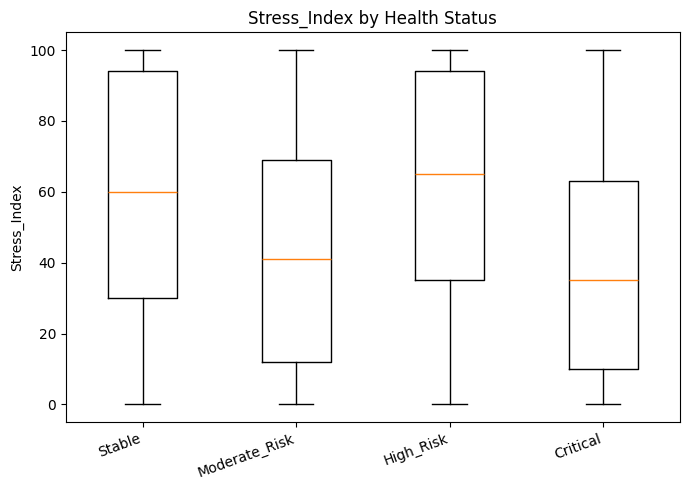

IoT_Device_Connectivity                        \
                                               mean        std median min   
Patient_Health_Status_Label                                                 
Critical                                  82.654038  23.336618   96.0  20   
High_Risk                                 81.462387  23.834853   94.0  20   
Moderate_Risk                             68.747253  27.292912   71.0  20   
Stable                                    69.614615  26.619538   72.0  20   

                                 Wearable_Device_Count                       \
                             max                  mean       std median min   
Patient_Health_Status_Label                                                   
Critical                     100              3.023928  1.412599    3.0   1   
High_Risk                    100              2.949850  1.426053    3.0   1   
Moderate_Risk                100              2.993007  1.418785    3.0   1   
Stable                       100              3.042042  1.448596    3.0   1   

                                 ... Cloud_Data_Transfer_Rate             \
                            max  ...                     mean        std   
Patient_Health_Status_Label      ...                                       
Critical                      5  ...                52.882213  27.538030   
High_Risk                     5  ...                52.875807  27.688980   
Moderate_Risk                 5  ...                51.870310  27.460451   
Stable                        5  ...                52.946727  26.811060   

                                                Medical_Alert_Frequency  \
                            median   min    max                    mean   
Patient_Health_Status_Label                                               
Critical                     51.79  5.02  99.83                7.162512   
High_Risk                    53.59  5.09  99.97                6.853561   
Moderate_Risk                51.72  5.01  99.88                6.988012   
Stable                       52.14  5.01  99.95                6.933934   

                                                      
                                  std median min max  
Patient_Health_Status_Label                           
Critical                     4.305049    7.0   0  14  
High_Risk                    4.425943    7.0   0  14  
Moderate_Risk                4.318548    7.0   0  14  
Stable                       4.378811    7.0   0  14  

[4 rows x 30 columns]

Saved figure: /content/OGA_XAI_HIoT_outputs/figures/Figure_4_IoT_Network_By_Health_Status.png


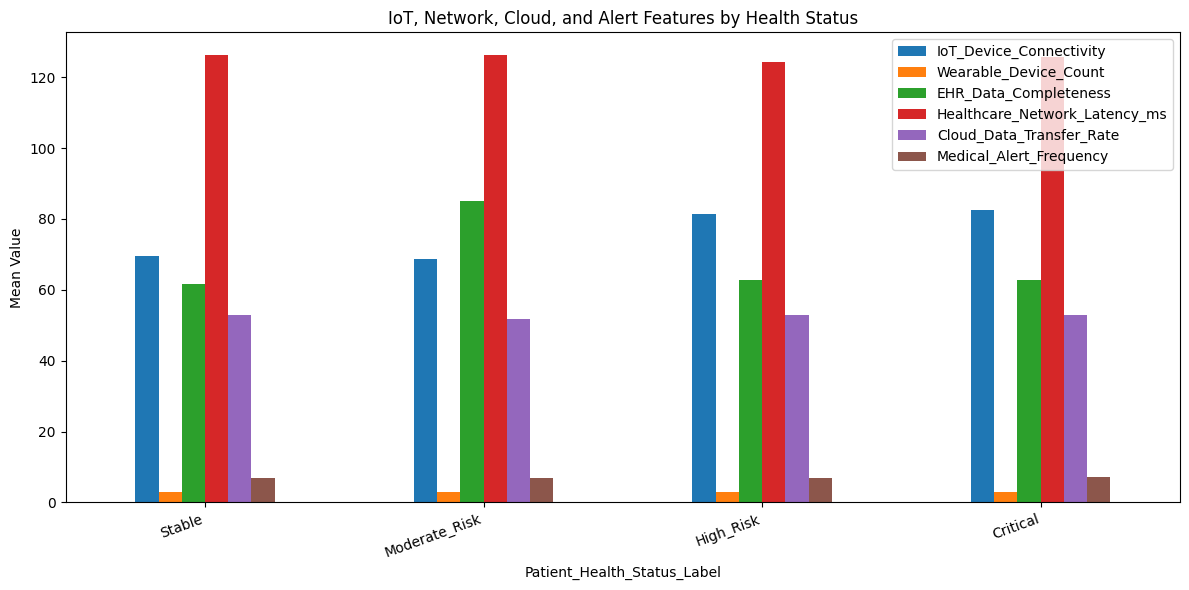

NOTE: Network latency and cloud transfer rate are proxy indicators only. The primary dataset does not contain separate collection and transmission timestamps.


In [ ]:
# ============================================================
# 7. RQ-oriented exploratory analysis
#    RQ1/RQ2/RQ3/RQ5/RQ6 from primary dataset
# ============================================================
input_features = [c for c in df_fe.columns if c not in [TARGET, "Patient_Health_Status_Label"]]
numeric_features = df_fe[input_features].select_dtypes(include=[np.number]).columns.tolist()

# High/low/variability analysis
rows = []
for col in numeric_features:
    s = df_fe[col]
    mean = s.mean()
    std = s.std()
    cv = std / mean if abs(mean) > EPS else np.nan
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outlier_pct = ((s < lower) | (s > upper)).mean() * 100
    if pd.isna(cv):
        consistency = "Undefined"
    elif cv < 0.10:
        consistency = "Stable"
    elif cv < 0.30:
        consistency = "Moderately Variable"
    else:
        consistency = "Highly Variable"
    rows.append({
        "Feature": col, "Mean": mean, "Std": std, "Minimum": s.min(), "Maximum": s.max(),
        "Median": s.median(), "IQR": iqr, "Coefficient_of_Variation": cv,
        "Skewness": s.skew(), "Outlier_Percentage": outlier_pct, "Consistency": consistency
    })
consistency_df = pd.DataFrame(rows).sort_values("Coefficient_of_Variation", ascending=False)
save_csv(consistency_df, "03_high_low_consistency_analysis.csv")
display(consistency_df.head(20))

plt.figure(figsize=(14, 6))
plt.bar(consistency_df["Feature"], consistency_df["Coefficient_of_Variation"])
plt.title("Feature Variability by Coefficient of Variation")
plt.ylabel("Coefficient of Variation")
plt.xticks(rotation=90)
save_fig("Figure_2_Feature_Variability.png")

# Activity-aware analysis
activity_features = ["Activity_Level", "Daily_Steps", "Sleep_Duration_Hours", "Stress_Index"]
activity_profile = df_fe.groupby("Patient_Health_Status_Label")[activity_features].agg(["mean", "std", "median", "min", "max"])
activity_profile.to_csv(TABLE_DIR / "04_activity_health_profile.csv")
display(activity_profile)

for feature in activity_features:
    plt.figure(figsize=(7, 5))
    data = [df_fe.loc[df_fe["Patient_Health_Status_Label"] == cls, feature].values for cls in CLASS_NAMES]
    plt.boxplot(data, labels=CLASS_NAMES, showfliers=False)
    plt.title(f"{feature} by Health Status")
    plt.ylabel(feature)
    plt.xticks(rotation=20, ha="right")
    save_fig(f"Figure_3_{feature}_by_Health_Status.png")

# IoT/network analysis
network_features = [
    "IoT_Device_Connectivity", "Wearable_Device_Count", "EHR_Data_Completeness",
    "Healthcare_Network_Latency_ms", "Cloud_Data_Transfer_Rate", "Medical_Alert_Frequency"
]
iot_profile = df_fe.groupby("Patient_Health_Status_Label")[network_features].agg(["mean", "std", "median", "min", "max"])
iot_profile.to_csv(TABLE_DIR / "05_iot_network_status_summary.csv")
display(iot_profile)

mean_iot = df_fe.groupby("Patient_Health_Status_Label")[network_features].mean().reindex(CLASS_NAMES)
mean_iot.plot(kind="bar", figsize=(12, 6))
plt.title("IoT, Network, Cloud, and Alert Features by Health Status")
plt.ylabel("Mean Value")
plt.xticks(rotation=20, ha="right")
save_fig("Figure_4_IoT_Network_By_Health_Status.png")

print("NOTE: Network latency and cloud transfer rate are proxy indicators only. The primary dataset does not contain separate collection and transmission timestamps.")

In [ ]:
# ============================================================
# 8. Clean train/validation/test split and preprocessing
# ============================================================
X = df_fe[input_features].copy()
y = df_fe[TARGET].copy()

# Outer untouched test split
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=SEED
)

# Validation split from training data. Test remains untouched.
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=VAL_SIZE_FROM_REMAINING,
    stratify=y_trainval, random_state=SEED
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)
print("Train distribution:")
print(y_train.value_counts().sort_index())
print("Validation distribution:")
print(y_val.value_counts().sort_index())
print("Test distribution:")
print(y_test.value_counts().sort_index())

# Preprocessing fitted only on training set
imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_val_imp = pd.DataFrame(imputer.transform(X_val), columns=X_val.columns, index=X_val.index)
X_test_imp = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns, index=X_test.index)

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_imp), columns=X_train.columns, index=X_train.index)
X_val_scaled = pd.DataFrame(scaler.transform(X_val_imp), columns=X_val.columns, index=X_val.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_imp), columns=X_test.columns, index=X_test.index)

# Also create trainval transform for final baseline fitting after validation/tuning.
X_trainval_imp = pd.DataFrame(imputer.fit_transform(X_trainval), columns=X_trainval.columns, index=X_trainval.index)
X_test_final_imp = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns, index=X_test.index)
X_trainval_scaled = pd.DataFrame(scaler.fit_transform(X_trainval_imp), columns=X_trainval.columns, index=X_trainval.index)
X_test_final_scaled = pd.DataFrame(scaler.transform(X_test_final_imp), columns=X_test.columns, index=X_test.index)

# Update group indices after feature list finalization
FEATURE_NAMES = X_train_scaled.columns.tolist()
GROUP_INDICES = {
    group: [FEATURE_NAMES.index(f) for f in feats if f in FEATURE_NAMES]
    for group, feats in FEATURE_GROUPS.items()
}
print("Group indices:", GROUP_INDICES)

# Save split indices and processed feature matrices
save_csv(pd.DataFrame({"Index": X_train.index, "Split": "train"}), "split_train_indices.csv")
save_csv(pd.DataFrame({"Index": X_val.index, "Split": "validation"}), "split_validation_indices.csv")
save_csv(pd.DataFrame({"Index": X_test.index, "Split": "test"}), "split_test_indices.csv")
X_train_scaled.to_csv(TABLE_DIR / "X_train_scaled.csv", index=False)
X_val_scaled.to_csv(TABLE_DIR / "X_validation_scaled.csv", index=False)
X_test_scaled.to_csv(TABLE_DIR / "X_test_scaled.csv", index=False)

Train shape: (2560, 28)
Validation shape: (640, 28)
Test shape: (800, 28)
Train distribution:
Patient_Health_Status
0    639
1    641
2    638
3    642
Name: count, dtype: int64
Validation distribution:
Patient_Health_Status
0    160
1    160
2    160
3    160
Name: count, dtype: int64
Test distribution:
Patient_Health_Status
0    200
1    200
2    199
3    201
Name: count, dtype: int64
Group indices: {'Physiological': [0, 1, 2, 3, 4, 5, 6, 17, 18, 19, 20], 'Behavioral': [7, 8, 9, 13, 21, 22, 23], 'IoT_Data_Quality': [10, 11, 12, 24, 25], 'Network_Cloud': [14, 15, 26, 27], 'Alert': [16]}
Saved: /content/OGA_XAI_HIoT_outputs/tables/split_train_indices.csv
Saved: /content/OGA_XAI_HIoT_outputs/tables/split_validation_indices.csv
Saved: /content/OGA_XAI_HIoT_outputs/tables/split_test_indices.csv


Training: LogisticRegression
Validation Macro F1: 0.7074
Test Macro F1      : 0.6757
Training: DecisionTree
Validation Macro F1: 0.667
Test Macro F1      : 0.6158
Training: RandomForest
Validation Macro F1: 0.834
Test Macro F1      : 0.7864
Training: ExtraTrees
Validation Macro F1: 0.8369
Test Macro F1      : 0.8211
Training: GradientBoosting
Validation Macro F1: 0.7983
Test Macro F1      : 0.7696
Training: HistGradientBoosting
Validation Macro F1: 0.8563
Test Macro F1      : 0.8132
Training: RBF_SVM
Validation Macro F1: 0.8419
Test Macro F1      : 0.7904
Training: KNN
Validation Macro F1: 0.7981
Test Macro F1      : 0.7515
Training: GaussianNB
Validation Macro F1: 0.6355
Test Macro F1      : 0.5987
Training: MLP
Validation Macro F1: 0.7818
Test Macro F1      : 0.7433
Training: XGBoost
Validation Macro F1: 0.8045
Test Macro F1      : 0.7786
Training: LightGBM
Validation Macro F1: 0.8469
Test Macro F1      : 0.8047
Training: CatBoost
Validation Macro F1: 0.8404
Test Macro F1      : 0.80

,Model,Val_Macro_F1,Test_Accuracy,Test_Macro_F1,Test_Balanced_Accuracy,Test_Mean_Absolute_Ordinal_Error,Test_Severe_Misclassification_Rate
3,ExtraTrees,0.836912,0.82125,0.821074,0.821310,0.281250,0.075000
5,HistGradientBoosting,0.856276,0.81375,0.813221,0.813866,0.301250,0.080000
11,LightGBM,0.846918,0.80500,0.804653,0.805116,0.311250,0.081250
12,CatBoost,0.840364,0.80500,0.804430,0.805110,1.250663,0.375303
6,RBF_SVM,0.841854,0.79125,0.790411,0.791328,0.333750,0.088750
2,RandomForest,0.834015,0.78625,0.786355,0.786291,0.322500,0.082500
10,XGBoost,0.804529,0.77875,0.778605,0.778835,0.346250,0.088750
4,GradientBoosting,0.798275,0.77000,0.769639,0.770072,0.351250,0.086250
7,KNN,0.798111,0.75250,0.751509,0.752652,0.391250,0.106250
9,MLP,0.781755,0.74375,0.743321,0.743840,0.381250,0.093750


Saved figure: /content/OGA_XAI_HIoT_outputs/figures/Figure_6_Baseline_Model_Performance_Comparison.png


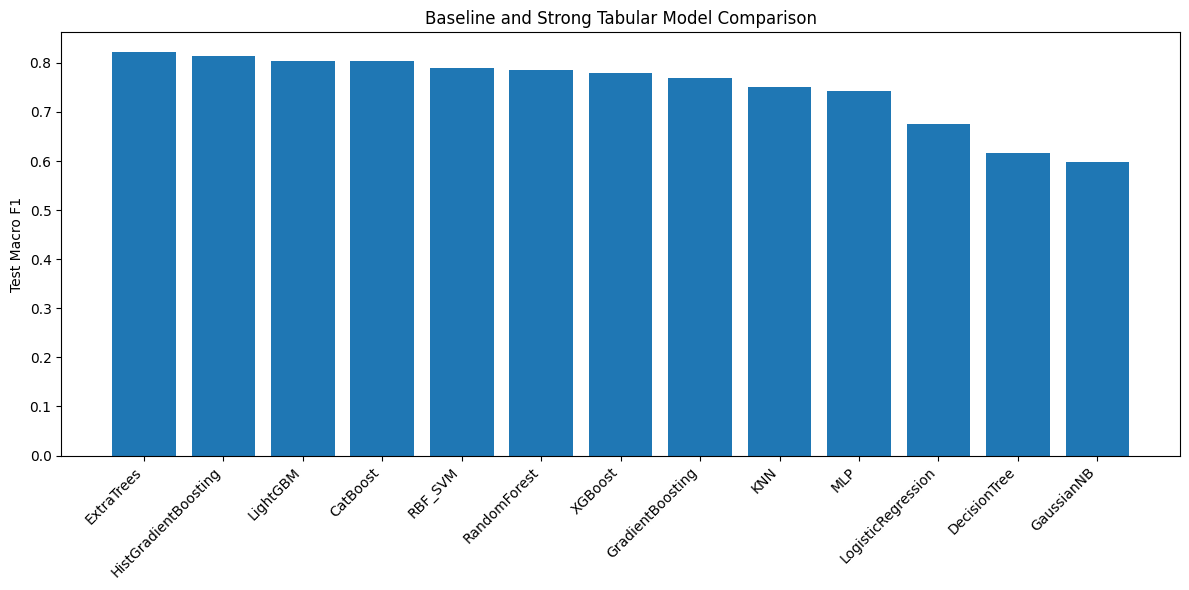

Best baseline by test macro F1: ExtraTrees


In [ ]:
# ============================================================
# 9. Baseline and strong tabular model training
# ============================================================


models = {
    "LogisticRegression": LogisticRegression(max_iter=3000, class_weight="balanced", random_state=SEED),
    "DecisionTree": DecisionTreeClassifier(class_weight="balanced", random_state=SEED),
    "RandomForest": RandomForestClassifier(n_estimators=500, class_weight="balanced", random_state=SEED, n_jobs=-1),
    "ExtraTrees": ExtraTreesClassifier(n_estimators=700, class_weight="balanced", random_state=SEED, n_jobs=-1),
    "GradientBoosting": GradientBoostingClassifier(random_state=SEED),
    "HistGradientBoosting": HistGradientBoostingClassifier(max_iter=500, learning_rate=0.03, l2_regularization=0.01, random_state=SEED),
    "RBF_SVM": SVC(kernel="rbf", C=10, gamma="scale", probability=True, class_weight="balanced", random_state=SEED),
    "KNN": KNeighborsClassifier(n_neighbors=15, weights="distance"),
    "GaussianNB": GaussianNB(),
    "MLP": MLPClassifier(hidden_layer_sizes=(128, 64), alpha=1e-3, learning_rate_init=5e-4, max_iter=500, early_stopping=True, random_state=SEED),
}

# Optional boosted models
try:
    from xgboost import XGBClassifier
    models["XGBoost"] = XGBClassifier(
        n_estimators=600, max_depth=3, learning_rate=0.03, subsample=0.9, colsample_bytree=0.9,
        objective="multi:softprob", num_class=NUM_CLASSES, eval_metric="mlogloss", random_state=SEED, n_jobs=-1
    )
except Exception as e:
    print("XGBoost unavailable:", e)

try:
    from lightgbm import LGBMClassifier
    models["LightGBM"] = LGBMClassifier(
        n_estimators=700, learning_rate=0.03, num_leaves=31, subsample=0.9, colsample_bytree=0.9,
        objective="multiclass", class_weight="balanced", random_state=SEED, n_jobs=-1, verbose=-1
    )
except Exception as e:
    print("LightGBM unavailable:", e)

try:
    from catboost import CatBoostClassifier
    models["CatBoost"] = CatBoostClassifier(
        iterations=700, depth=5, learning_rate=0.03, loss_function="MultiClass", random_seed=SEED,
        verbose=False, allow_writing_files=False
    )
except Exception as e:
    print("CatBoost unavailable:", e)

baseline_rows = []
fitted_models = {}

for name, model in models.items():
    print("=" * 90)
    print("Training:", name)
    print("=" * 90)
    try:
        model.fit(X_train_scaled, y_train)
        val_pred = model.predict(X_val_scaled)
        test_pred = model.predict(X_test_scaled)
        val_proba = model.predict_proba(X_val_scaled) if hasattr(model, "predict_proba") else None
        test_proba = model.predict_proba(X_test_scaled) if hasattr(model, "predict_proba") else None
        val_metrics = compute_metrics(y_val, val_pred, val_proba, prefix="Val_")
        test_metrics = compute_metrics(y_test, test_pred, test_proba, prefix="Test_")
        row = {"Model": name, **val_metrics, **test_metrics}
        baseline_rows.append(row)
        fitted_models[name] = model
        print("Validation Macro F1:", round(val_metrics["Val_Macro_F1"], 4))
        print("Test Macro F1      :", round(test_metrics["Test_Macro_F1"], 4))
    except Exception as e:
        print(f"⚠ Model {name} failed: {e}")

baseline_results = pd.DataFrame(baseline_rows).sort_values("Test_Macro_F1", ascending=False)
save_csv(baseline_results, "07a_baseline_model_performance.csv")
display(baseline_results[["Model", "Val_Macro_F1", "Test_Accuracy", "Test_Macro_F1", "Test_Balanced_Accuracy", "Test_Mean_Absolute_Ordinal_Error", "Test_Severe_Misclassification_Rate"]])

plt.figure(figsize=(12, 6))
plt.bar(baseline_results["Model"], baseline_results["Test_Macro_F1"])
plt.title("Baseline and Strong Tabular Model Comparison")
plt.ylabel("Test Macro F1")
plt.xticks(rotation=45, ha="right")
save_fig("Figure_6_Baseline_Model_Performance_Comparison.png")

best_baseline_name = baseline_results.iloc[0]["Model"]
best_baseline = fitted_models[best_baseline_name]
print("Best baseline by test macro F1:", best_baseline_name)

In [ ]:
# ============================================================
# 10. Optional hyperparameter tuning for selected strong baselines
# ============================================================


if TUNE_MODELS:
    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    search_spaces = {
        "ExtraTrees_Tuned": (
            ExtraTreesClassifier(class_weight="balanced", random_state=SEED, n_jobs=-1),
            {
                "n_estimators": [300, 500, 700, 1000],
                "max_depth": [None, 6, 10, 15, 20],
                "min_samples_split": [2, 4, 8, 12],
                "min_samples_leaf": [1, 2, 4],
                "max_features": ["sqrt", "log2", None],
            }
        ),
        "RandomForest_Tuned": (
            RandomForestClassifier(class_weight="balanced", random_state=SEED, n_jobs=-1),
            {
                "n_estimators": [300, 500, 700, 1000],
                "max_depth": [None, 6, 10, 15, 20],
                "min_samples_split": [2, 4, 8, 12],
                "min_samples_leaf": [1, 2, 4],
                "max_features": ["sqrt", "log2", None],
            }
        ),
        "RBF_SVM_Tuned": (
            SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=SEED),
            {
                "C": [0.1, 1, 3, 10, 30, 100],
                "gamma": ["scale", "auto", 0.001, 0.003, 0.01, 0.03, 0.1],
            }
        ),
    }

    tuned_rows = []
    tuned_models = {}
    for name, (estimator, param_dist) in search_spaces.items():
        print("=" * 90)
        print("Tuning:", name)
        print("=" * 90)
        search = RandomizedSearchCV(
            estimator=estimator,
            param_distributions=param_dist,
            n_iter=N_ITER_TUNING,
            scoring="f1_macro",
            cv=cv,
            random_state=SEED,
            n_jobs=-1,
            verbose=1,
            refit=True
        )
        search.fit(X_train_scaled, y_train)
        tuned_model = search.best_estimator_
        val_pred = tuned_model.predict(X_val_scaled)
        test_pred = tuned_model.predict(X_test_scaled)
        val_proba = tuned_model.predict_proba(X_val_scaled) if hasattr(tuned_model, "predict_proba") else None
        test_proba = tuned_model.predict_proba(X_test_scaled) if hasattr(tuned_model, "predict_proba") else None
        row = {
            "Model": name,
            "Best_Params": json.dumps(search.best_params_),
            "Best_CV_Macro_F1": search.best_score_,
            **compute_metrics(y_val, val_pred, val_proba, prefix="Val_"),
            **compute_metrics(y_test, test_pred, test_proba, prefix="Test_")
        }
        tuned_rows.append(row)
        tuned_models[name] = tuned_model
        print("Best params:", search.best_params_)
        print("Test macro F1:", row["Test_Macro_F1"])

    tuned_results = pd.DataFrame(tuned_rows).sort_values("Test_Macro_F1", ascending=False)
    save_csv(tuned_results, "07b_tuned_baseline_model_performance.csv")
    display(tuned_results[["Model", "Best_CV_Macro_F1", "Val_Macro_F1", "Test_Accuracy", "Test_Macro_F1", "Test_Severe_Misclassification_Rate"]])

    # Merge tuned models into fitted model dictionary for later comparison
    fitted_models.update(tuned_models)
else:
    tuned_results = pd.DataFrame()
    tuned_models = {}
    print("Hyperparameter tuning skipped.")

Tuning: ExtraTrees_Tuned
Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best params: {'n_estimators': 1000, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20}
Test macro F1: 0.8109298063817805
Tuning: RandomForest_Tuned
Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best params: {'n_estimators': 1000, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20}
Test macro F1: 0.7837112395037833
Tuning: RBF_SVM_Tuned
Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best params: {'gamma': 0.03, 'C': 3}
Test macro F1: 0.8118888900393239
Saved: /content/OGA_XAI_HIoT_outputs/tables/07b_tuned_baseline_model_performance.csv


,Model,Best_CV_Macro_F1,Val_Macro_F1,Test_Accuracy,Test_Macro_F1,Test_Severe_Misclassification_Rate
2,RBF_SVM_Tuned,0.813942,0.830863,0.81250,0.811889,0.07875
0,ExtraTrees_Tuned,0.807478,0.835398,0.81125,0.810930,0.07625
1,RandomForest_Tuned,0.800122,0.829219,0.78375,0.783711,0.08625


In [ ]:
# ============================================================
# 11. Optional TabNet advanced baseline without test leakage
# ============================================================
# IMPORTANT FIX: validation set is used for early stopping; test set is NOT used during training.

advanced_rows = []

if RUN_TABNET_BASELINE:
    try:
        from pytorch_tabnet.tab_model import TabNetClassifier
        print("Training TabNet baseline...")
        tabnet = TabNetClassifier(
            n_d=16, n_a=16, n_steps=4, gamma=1.5, lambda_sparse=1e-4,
            optimizer_fn=torch.optim.Adam,
            optimizer_params=dict(lr=1e-2, weight_decay=1e-5),
            mask_type="entmax", seed=SEED, verbose=10
        )
        tabnet.fit(
            X_train_scaled.values.astype(np.float32), y_train.values.astype(np.int64),
            eval_set=[(X_val_scaled.values.astype(np.float32), y_val.values.astype(np.int64))],
            eval_name=["validation"],
            eval_metric=["accuracy"],
            max_epochs=150, patience=25, batch_size=256, virtual_batch_size=128,
            num_workers=0, drop_last=False
        )
        tabnet_pred = tabnet.predict(X_test_scaled.values.astype(np.float32))
        tabnet_proba = tabnet.predict_proba(X_test_scaled.values.astype(np.float32))
        row = {"Model": "TabNet", **compute_metrics(y_test, tabnet_pred, tabnet_proba, prefix="Test_")}
        advanced_rows.append(row)
        fitted_models["TabNet"] = tabnet
        print_report(y_test, tabnet_pred, "TabNet Test Report")
    except Exception as e:
        print("⚠ TabNet baseline skipped/failed:", e)
else:
    print("TabNet baseline skipped by configuration.")

advanced_results = pd.DataFrame(advanced_rows)
if not advanced_results.empty:
    save_csv(advanced_results, "07c_advanced_tabular_baselines.csv")
    display(advanced_results)

Training TabNet baseline...
epoch 0  | loss: 1.78502 | validation_accuracy: 0.31719 |  0:00:00s
epoch 10 | loss: 0.85796 | validation_accuracy: 0.66562 |  0:00:03s
epoch 20 | loss: 0.61    | validation_accuracy: 0.73125 |  0:00:07s
epoch 30 | loss: 0.4662  | validation_accuracy: 0.76719 |  0:00:11s
epoch 40 | loss: 0.35339 | validation_accuracy: 0.77031 |  0:00:15s
epoch 50 | loss: 0.28804 | validation_accuracy: 0.775   |  0:00:18s
epoch 60 | loss: 0.24005 | validation_accuracy: 0.76406 |  0:00:23s
epoch 70 | loss: 0.19689 | validation_accuracy: 0.79844 |  0:00:26s
epoch 80 | loss: 0.19678 | validation_accuracy: 0.79844 |  0:00:30s
epoch 90 | loss: 0.15123 | validation_accuracy: 0.79062 |  0:00:34s
epoch 100| loss: 0.15395 | validation_accuracy: 0.79219 |  0:00:38s
epoch 110| loss: 0.12557 | validation_accuracy: 0.79375 |  0:00:41s

Early stopping occurred at epoch 118 with best_epoch = 93 and best_validation_accuracy = 0.81406
TabNet Test Report
               precision    recall  f1-

,Model,Test_Accuracy,Test_Balanced_Accuracy,Test_Macro_Precision,Test_Macro_Recall,Test_Macro_F1,Test_Weighted_F1,Test_MCC,Test_Cohen_Kappa,Test_Mean_Absolute_Ordinal_Error,Test_Median_Absolute_Ordinal_Error,Test_Severe_Misclassification_Rate,Test_Max_Ordinal_Error,Test_Multiclass_ROC_AUC_OVR,Test_Multiclass_Brier,Test_ECE
0,TabNet,0.77,0.770009,0.770225,0.770009,0.770036,0.770003,0.693373,0.693326,0.35625,0.0,0.09375,3,0.926969,0.373005,0.140682


In [ ]:
# ============================================================
# 12. Proposed Model: OGA-XAI-HIoT
# ============================================================


class NumericTokenizer(nn.Module):
    def __init__(self, n_features, d_token):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(n_features, d_token) * 0.02)
        self.bias = nn.Parameter(torch.zeros(n_features, d_token))

    def forward(self, x):
        # x: [batch, n_features]
        return x.unsqueeze(-1) * self.weight.unsqueeze(0) + self.bias.unsqueeze(0)


class GroupEncoder(nn.Module):
    def __init__(self, n_features, d_token=32, n_heads=2, n_layers=1, dropout=0.2):
        super().__init__()
        self.tokenizer = NumericTokenizer(n_features, d_token)
        layer = nn.TransformerEncoderLayer(
            d_model=d_token,
            nhead=n_heads,
            dim_feedforward=d_token * 2,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )
        self.encoder = nn.TransformerEncoder(layer, num_layers=n_layers)
        self.norm = nn.LayerNorm(d_token)

    def forward(self, x):
        tokens = self.tokenizer(x)
        tokens = self.encoder(tokens)
        pooled = tokens.mean(dim=1)
        return self.norm(pooled)


class CrossGroupAttention(nn.Module):
    def __init__(self, d_token=32, n_heads=2, dropout=0.2):
        super().__init__()
        self.query = nn.Parameter(torch.zeros(1, 1, d_token))
        nn.init.normal_(self.query, std=0.02)
        self.attn = nn.MultiheadAttention(d_token, n_heads, dropout=dropout, batch_first=True)
        self.norm1 = nn.LayerNorm(d_token)
        self.ffn = nn.Sequential(
            nn.Linear(d_token, d_token * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_token * 2, d_token)
        )
        self.norm2 = nn.LayerNorm(d_token)

    def forward(self, group_tokens, return_attention=False):
        # group_tokens: [batch, n_groups, d_token]
        q = self.query.expand(group_tokens.shape[0], -1, -1)
        fused, attn_weights = self.attn(q, group_tokens, group_tokens, need_weights=True, average_attn_weights=True)
        fused = self.norm1(q + fused)
        fused = self.norm2(fused + self.ffn(fused))
        fused = fused.squeeze(1)
        if return_attention:
            # attn_weights: [batch, 1, n_groups]
            return fused, attn_weights.squeeze(1)
        return fused


class OGAXAIHIoT(nn.Module):
    def __init__(self, group_indices, d_token=32, n_heads=2, n_layers=1, dropout=0.25, n_classes=4):
        super().__init__()
        self.group_names = list(group_indices.keys())
        self.group_indices = {g: torch.tensor(idx, dtype=torch.long) for g, idx in group_indices.items() if len(idx) > 0}
        self.group_names = list(self.group_indices.keys())
        self.encoders = nn.ModuleDict({
            g: GroupEncoder(len(idx), d_token=d_token, n_heads=n_heads, n_layers=n_layers, dropout=dropout)
            for g, idx in self.group_indices.items()
        })
        self.fusion = CrossGroupAttention(d_token=d_token, n_heads=n_heads, dropout=dropout)
        self.classifier = nn.Sequential(
            nn.Linear(d_token, d_token),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_token, n_classes)
        )

    def forward(self, x, return_attention=False):
        group_embeddings = []
        for g in self.group_names:
            idx = self.group_indices[g].to(x.device)
            gx = x.index_select(dim=1, index=idx)
            group_embeddings.append(self.encoders[g](gx))
        group_tokens = torch.stack(group_embeddings, dim=1)
        if return_attention:
            fused, attn = self.fusion(group_tokens, return_attention=True)
            return self.classifier(fused), attn
        fused = self.fusion(group_tokens)
        return self.classifier(fused)


class OrdinalCELoss(nn.Module):
    def __init__(self, n_classes=4, ordinal_lambda=0.1, class_weights=None):
        super().__init__()
        self.n_classes = n_classes
        self.ordinal_lambda = ordinal_lambda
        if class_weights is not None:
            self.register_buffer("class_weights", torch.tensor(class_weights, dtype=torch.float32))
        else:
            self.class_weights = None

    def forward(self, logits, target):
        ce = F.cross_entropy(logits, target, weight=self.class_weights)
        probs = F.softmax(logits, dim=1)
        class_idx = torch.arange(self.n_classes, device=logits.device, dtype=torch.float32)
        expected = torch.sum(probs * class_idx.unsqueeze(0), dim=1)
        ordinal = torch.mean(((expected - target.float()) / (self.n_classes - 1)) ** 2)
        return ce + self.ordinal_lambda * ordinal


def make_loader(X_df, y_ser, batch_size=64, shuffle=False):
    X_t = torch.tensor(X_df.values.astype(np.float32))
    y_t = torch.tensor(y_ser.values.astype(np.int64))
    return DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=shuffle)


def predict_torch_model(model, X_df, batch_size=256, return_attention=False):
    model.eval()
    loader = DataLoader(torch.tensor(X_df.values.astype(np.float32)), batch_size=batch_size, shuffle=False)
    logits_list, attn_list = [], []
    with torch.no_grad():
        for batch_X in loader:
            batch_X = batch_X.to(DEVICE)
            if return_attention:
                logits, attn = model(batch_X, return_attention=True)
                attn_list.append(attn.cpu().numpy())
            else:
                logits = model(batch_X)
            logits_list.append(logits.cpu().numpy())
    logits = np.vstack(logits_list)
    proba = torch.softmax(torch.tensor(logits), dim=1).numpy()
    pred = np.argmax(proba, axis=1)
    if return_attention:
        attn = np.vstack(attn_list)
        return pred, proba, logits, attn
    return pred, proba, logits


def train_oga_model(
    X_train_df, y_train_ser, X_val_df, y_val_ser, group_indices,
    d_token=32, n_heads=2, n_layers=1, dropout=0.25, lr=5e-4, weight_decay=1e-3,
    ordinal_lambda=0.1, batch_size=64, max_epochs=200, patience=20, seed=42
):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    model = OGAXAIHIoT(
        group_indices=group_indices, d_token=d_token, n_heads=n_heads,
        n_layers=n_layers, dropout=dropout, n_classes=NUM_CLASSES
    ).to(DEVICE)

    # Classes are balanced, but class weights are retained for safety.
    counts = np.bincount(y_train_ser.values, minlength=NUM_CLASSES)
    weights = counts.sum() / (NUM_CLASSES * np.maximum(counts, 1))
    criterion = OrdinalCELoss(n_classes=NUM_CLASSES, ordinal_lambda=ordinal_lambda, class_weights=weights).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", patience=6, factor=0.5)

    train_loader = make_loader(X_train_df, y_train_ser, batch_size=batch_size, shuffle=True)
    best_state = None
    best_val_f1 = -np.inf
    best_epoch = -1
    bad_epochs = 0
    history = []

    for epoch in range(1, max_epochs + 1):
        model.train()
        losses = []
        for batch_X, batch_y in train_loader:
            batch_X = batch_X.to(DEVICE)
            batch_y = batch_y.to(DEVICE)
            optimizer.zero_grad()
            logits = model(batch_X)
            loss = criterion(logits, batch_y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            losses.append(loss.item())

        val_pred, val_proba, _ = predict_torch_model(model, X_val_df)
        val_f1 = f1_score(y_val_ser, val_pred, average="macro", zero_division=0)
        val_acc = accuracy_score(y_val_ser, val_pred)
        scheduler.step(val_f1)
        history.append({"Epoch": epoch, "Train_Loss": float(np.mean(losses)), "Val_Macro_F1": val_f1, "Val_Accuracy": val_acc})

        if val_f1 > best_val_f1 + 1e-5:
            best_val_f1 = val_f1
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1

        if epoch % 10 == 0 or epoch == 1:
            print(f"Epoch {epoch:03d} | loss={np.mean(losses):.4f} | val_macro_f1={val_f1:.4f} | val_acc={val_acc:.4f}")

        if bad_epochs >= patience:
            print(f"Early stopping at epoch {epoch}. Best epoch={best_epoch}, best validation macro F1={best_val_f1:.4f}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    history_df = pd.DataFrame(history)
    return model, history_df, best_val_f1, best_epoch

Epoch 001 | loss=1.2976 | val_macro_f1=0.6200 | val_acc=0.6203
Epoch 010 | loss=0.8470 | val_macro_f1=0.7223 | val_acc=0.7219
Epoch 020 | loss=0.7625 | val_macro_f1=0.7703 | val_acc=0.7703
Epoch 030 | loss=0.7196 | val_macro_f1=0.7592 | val_acc=0.7594
Epoch 040 | loss=0.7006 | val_macro_f1=0.7736 | val_acc=0.7734
Epoch 050 | loss=0.6704 | val_macro_f1=0.7637 | val_acc=0.7641
Epoch 060 | loss=0.6872 | val_macro_f1=0.7688 | val_acc=0.7688
Early stopping at epoch 60. Best epoch=40, best validation macro F1=0.7736
Saved: /content/OGA_XAI_HIoT_outputs/tables/07d_proposed_OGA_XAI_HIoT_performance.csv


,0
Model,OGA-XAI-HIoT
Best_Epoch,40
Best_Val_Macro_F1,0.773647
Val_Accuracy,0.773438
Val_Balanced_Accuracy,0.773438
Val_Macro_Precision,0.77998
Val_Macro_Recall,0.773438
Val_Macro_F1,0.773647
Val_Weighted_F1,0.773647
Val_MCC,0.699725


Proposed OGA-XAI-HIoT Test Report
               precision    recall  f1-score   support

       Stable       0.79      0.79      0.79       200
Moderate_Risk       0.72      0.78      0.75       200
    High_Risk       0.75      0.75      0.75       199
     Critical       0.73      0.67      0.70       201

     accuracy                           0.75       800
    macro avg       0.75      0.75      0.75       800
 weighted avg       0.75      0.75      0.75       800

Saved figure: /content/OGA_XAI_HIoT_outputs/figures/Figure_7_Confusion_Matrix_OGA_XAI_HIoT.png


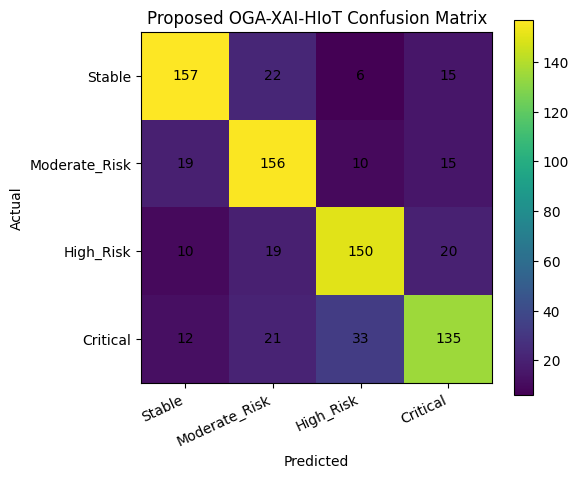

Saved: /content/OGA_XAI_HIoT_outputs/tables/14_test_predictions_OGA_XAI_HIoT.csv
Saved figure: /content/OGA_XAI_HIoT_outputs/figures/Figure_8_OGA_Training_Curve.png


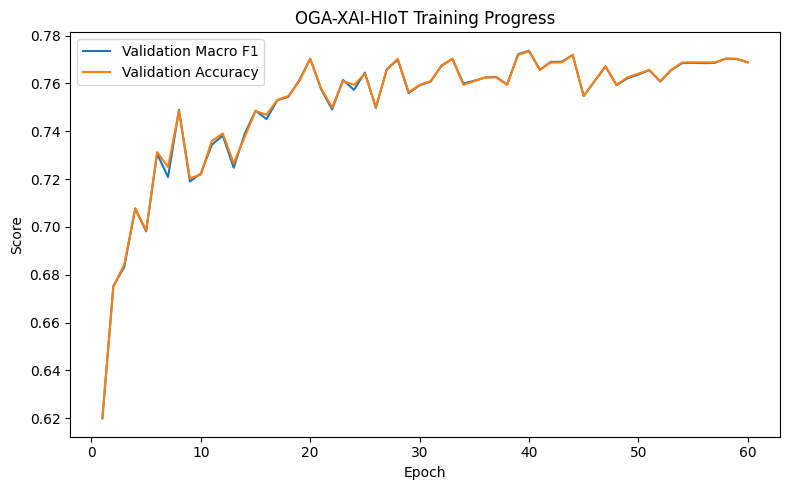

PosixPath('/content/OGA_XAI_HIoT_outputs/figures/Figure_8_OGA_Training_Curve.png')

In [ ]:
# ============================================================
# 13. Train proposed OGA-XAI-HIoT model
# ============================================================
OGA_CONFIG = {
    "d_token": 32,
    "n_heads": 2,
    "n_layers": 1,
    "dropout": 0.25,
    "lr": 5e-4,
    "weight_decay": 1e-3,
    "ordinal_lambda": 0.10,
    "batch_size": 64,
    "max_epochs": 200,
    "patience": 20,
}

oga_model, oga_history, best_val_f1, best_epoch = train_oga_model(
    X_train_scaled, y_train, X_val_scaled, y_val,
    GROUP_INDICES,
    seed=SEED,
    **OGA_CONFIG
)

oga_history.to_csv(TABLE_DIR / "OGA_training_history.csv", index=False)

oga_test_pred, oga_test_proba, oga_test_logits, oga_test_attention = predict_torch_model(
    oga_model, X_test_scaled, return_attention=True
)
oga_val_pred, oga_val_proba, oga_val_logits, oga_val_attention = predict_torch_model(
    oga_model, X_val_scaled, return_attention=True
)

oga_val_metrics = compute_metrics(y_val, oga_val_pred, oga_val_proba, prefix="Val_")
oga_test_metrics = compute_metrics(y_test, oga_test_pred, oga_test_proba, prefix="Test_")
oga_result = pd.DataFrame([{ "Model": "OGA-XAI-HIoT", "Best_Epoch": best_epoch, "Best_Val_Macro_F1": best_val_f1, **oga_val_metrics, **oga_test_metrics }])
save_csv(oga_result, "07d_proposed_OGA_XAI_HIoT_performance.csv")
display(oga_result.T)

print_report(y_test, oga_test_pred, "Proposed OGA-XAI-HIoT Test Report")
cm_oga = plot_confusion_matrix(y_test, oga_test_pred, "Proposed OGA-XAI-HIoT Confusion Matrix", "Figure_7_Confusion_Matrix_OGA_XAI_HIoT.png")
pd.DataFrame(cm_oga, index=CLASS_NAMES, columns=CLASS_NAMES).to_csv(TABLE_DIR / "07_confusion_matrix_proposed.csv")

# Save predictions
pred_df = pd.DataFrame({
    "True_ID": y_test.values,
    "True_Label": [ID_TO_LABEL[int(v)] for v in y_test.values],
    "Predicted_ID": oga_test_pred,
    "Predicted_Label": [ID_TO_LABEL[int(v)] for v in oga_test_pred],
})
for i, cls in enumerate(CLASS_NAMES):
    pred_df[f"Prob_{cls}"] = oga_test_proba[:, i]
pred_df["Ordinal_Error"] = np.abs(pred_df["True_ID"] - pred_df["Predicted_ID"])
save_csv(pred_df, "14_test_predictions_OGA_XAI_HIoT.csv")

# Training curve
plt.figure(figsize=(8, 5))
plt.plot(oga_history["Epoch"], oga_history["Val_Macro_F1"], label="Validation Macro F1")
plt.plot(oga_history["Epoch"], oga_history["Val_Accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("OGA-XAI-HIoT Training Progress")
plt.legend()
save_fig("Figure_8_OGA_Training_Curve.png")

In [ ]:
# ============================================================
# 14. Multi-seed validation for proposed model
# ============================================================


if RUN_OGA_MULTISEED:
    seeds = [42, 7, 21, 100, 2025]
    multiseed_rows = []
    for s in seeds:
        print("=" * 80)
        print("Training OGA-XAI-HIoT with seed", s)
        print("=" * 80)
        m, hist, vf1, be = train_oga_model(
            X_train_scaled, y_train, X_val_scaled, y_val,
            GROUP_INDICES,
            seed=s,
            **OGA_CONFIG
        )
        pred, proba, logits = predict_torch_model(m, X_test_scaled)
        row = {"Seed": s, "Best_Epoch": be, "Best_Val_Macro_F1": vf1, **compute_metrics(y_test, pred, proba)}
        multiseed_rows.append(row)
    oga_multiseed = pd.DataFrame(multiseed_rows)
    save_csv(oga_multiseed, "13_statistical_validation_OGA_multiseed.csv")
    display(oga_multiseed)
    summary = oga_multiseed.drop(columns=["Seed", "Best_Epoch"]).agg(["mean", "std", "min", "max"]).T.reset_index().rename(columns={"index": "Metric"})
    save_csv(summary, "13b_statistical_validation_summary_OGA.csv")
    display(summary)
else:
    print("Multi-seed OGA validation skipped by configuration.")

Training OGA-XAI-HIoT with seed 42
Epoch 001 | loss=1.2976 | val_macro_f1=0.6200 | val_acc=0.6203
Epoch 010 | loss=0.8470 | val_macro_f1=0.7223 | val_acc=0.7219
Epoch 020 | loss=0.7625 | val_macro_f1=0.7703 | val_acc=0.7703
Epoch 030 | loss=0.7196 | val_macro_f1=0.7592 | val_acc=0.7594
Epoch 040 | loss=0.7006 | val_macro_f1=0.7736 | val_acc=0.7734
Epoch 050 | loss=0.6704 | val_macro_f1=0.7637 | val_acc=0.7641
Epoch 060 | loss=0.6872 | val_macro_f1=0.7688 | val_acc=0.7688
Early stopping at epoch 60. Best epoch=40, best validation macro F1=0.7736
Training OGA-XAI-HIoT with seed 7
Epoch 001 | loss=1.2620 | val_macro_f1=0.6597 | val_acc=0.6625
Epoch 010 | loss=0.8471 | val_macro_f1=0.7273 | val_acc=0.7281
Epoch 020 | loss=0.7690 | val_macro_f1=0.7311 | val_acc=0.7312
Epoch 030 | loss=0.7108 | val_macro_f1=0.7530 | val_acc=0.7531
Epoch 040 | loss=0.6762 | val_macro_f1=0.7744 | val_acc=0.7734
Epoch 050 | loss=0.6508 | val_macro_f1=0.7968 | val_acc=0.7969
Epoch 060 | loss=0.6612 | val_macro_f

,Seed,Best_Epoch,Best_Val_Macro_F1,Accuracy,Balanced_Accuracy,Macro_Precision,Macro_Recall,Macro_F1,Weighted_F1,MCC,Cohen_Kappa,Mean_Absolute_Ordinal_Error,Median_Absolute_Ordinal_Error,Severe_Misclassification_Rate,Max_Ordinal_Error,Multiclass_ROC_AUC_OVR,Multiclass_Brier,ECE
0,42,40,0.773647,0.74750,0.747603,0.748006,0.747603,0.747152,0.747084,0.663747,0.663343,0.38500,0.0,0.09875,3,0.919921,0.367508,0.027986
1,7,108,0.825330,0.77625,0.776341,0.776184,0.776341,0.776174,0.776092,0.701722,0.701668,0.35625,0.0,0.09625,3,0.940738,0.315582,0.042612
2,21,98,0.814171,0.77375,0.773897,0.773693,0.773897,0.773219,0.773139,0.698687,0.698350,0.36000,0.0,0.09750,3,0.933094,0.331804,0.046588
3,100,105,0.806375,0.76375,0.763928,0.764054,0.763928,0.762980,0.762882,0.685607,0.685021,0.37250,0.0,0.09625,3,0.934577,0.335560,0.048155
4,2025,43,0.768776,0.75000,0.750003,0.751650,0.750003,0.750312,0.750281,0.666967,0.666657,0.37625,0.0,0.09375,3,0.923227,0.362009,0.043516


Saved: /content/OGA_XAI_HIoT_outputs/tables/13b_statistical_validation_summary_OGA.csv


,Metric,mean,std,min,max
0,Best_Val_Macro_F1,0.797660,0.025125,0.768776,0.825330
1,Accuracy,0.762250,0.013211,0.747500,0.776250
2,Balanced_Accuracy,0.762354,0.013243,0.747603,0.776341
3,Macro_Precision,0.762718,0.012674,0.748006,0.776184
4,Macro_Recall,0.762354,0.013243,0.747603,0.776341
5,Macro_F1,0.761967,0.013084,0.747152,0.776174
6,Weighted_F1,0.761896,0.013069,0.747084,0.776092
7,MCC,0.683346,0.017540,0.663747,0.701722
8,Cohen_Kappa,0.683008,0.017619,0.663343,0.701668
9,Mean_Absolute_Ordinal_Error,0.370000,0.011826,0.356250,0.385000


Saved: /content/OGA_XAI_HIoT_outputs/tables/12_calibration_results.csv


,0
Model,OGA-XAI-HIoT_TemperatureScaled
Calibrated_Test_Accuracy,0.7475
Calibrated_Test_Balanced_Accuracy,0.747603
Calibrated_Test_Macro_Precision,0.748006
Calibrated_Test_Macro_Recall,0.747603
Calibrated_Test_Macro_F1,0.747152
Calibrated_Test_Weighted_F1,0.747084
Calibrated_Test_MCC,0.663747
Calibrated_Test_Cohen_Kappa,0.663343
Calibrated_Test_Mean_Absolute_Ordinal_Error,0.385


Saved: /content/OGA_XAI_HIoT_outputs/tables/12b_calibration_curve_bins.csv
Saved figure: /content/OGA_XAI_HIoT_outputs/figures/Figure_13_Calibration_Curve.png


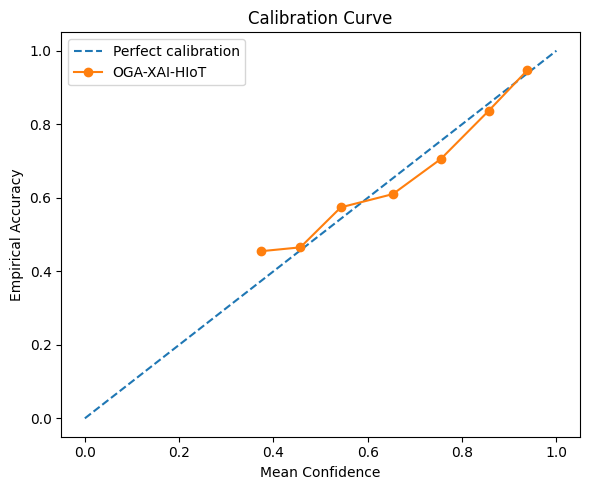

PosixPath('/content/OGA_XAI_HIoT_outputs/figures/Figure_13_Calibration_Curve.png')

In [ ]:
# ============================================================
# 15. Temperature scaling calibration for OGA-XAI-HIoT
# ============================================================
class TemperatureScaler(nn.Module):
    def __init__(self):
        super().__init__()
        self.log_temperature = nn.Parameter(torch.zeros(1))

    def forward(self, logits):
        temperature = torch.exp(self.log_temperature) + 1e-8
        return logits / temperature


def fit_temperature(logits_val, y_val_arr, max_iter=200):
    scaler = TemperatureScaler().to(DEVICE)
    logits_t = torch.tensor(logits_val, dtype=torch.float32, device=DEVICE)
    y_t = torch.tensor(y_val_arr, dtype=torch.long, device=DEVICE)
    optimizer = torch.optim.LBFGS(scaler.parameters(), lr=0.01, max_iter=max_iter)
    criterion = nn.CrossEntropyLoss()

    def closure():
        optimizer.zero_grad()
        loss = criterion(scaler(logits_t), y_t)
        loss.backward()
        return loss

    optimizer.step(closure)
    return scaler

calibrator = fit_temperature(oga_val_logits, y_val.values)
with torch.no_grad():
    calibrated_logits = calibrator(torch.tensor(oga_test_logits, dtype=torch.float32, device=DEVICE)).cpu()
calibrated_proba = torch.softmax(calibrated_logits, dim=1).numpy()
calibrated_pred = calibrated_proba.argmax(axis=1)

calibration_metrics = compute_metrics(y_test, calibrated_pred, calibrated_proba, prefix="Calibrated_Test_")
calibration_df = pd.DataFrame([{ "Model": "OGA-XAI-HIoT_TemperatureScaled", **calibration_metrics }])
save_csv(calibration_df, "12_calibration_results.csv")
display(calibration_df.T)

# Reliability curve using max-confidence bins
conf = calibrated_proba.max(axis=1)
correct = (calibrated_pred == y_test.values).astype(float)
bins = np.linspace(0, 1, 11)
bin_rows = []
for i in range(len(bins)-1):
    low, high = bins[i], bins[i+1]
    mask = (conf > low) & (conf <= high)
    if mask.sum() > 0:
        bin_rows.append({"Bin_Low": low, "Bin_High": high, "Count": int(mask.sum()), "Accuracy": correct[mask].mean(), "Confidence": conf[mask].mean()})
calib_curve = pd.DataFrame(bin_rows)
save_csv(calib_curve, "12b_calibration_curve_bins.csv")

plt.figure(figsize=(6, 5))
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
if not calib_curve.empty:
    plt.plot(calib_curve["Confidence"], calib_curve["Accuracy"], marker="o", label="OGA-XAI-HIoT")
plt.xlabel("Mean Confidence")
plt.ylabel("Empirical Accuracy")
plt.title("Calibration Curve")
plt.legend()
save_fig("Figure_13_Calibration_Curve.png")

Saved: /content/OGA_XAI_HIoT_outputs/tables/07_model_performance_comparison.csv


,Model,Test_Accuracy,Test_Balanced_Accuracy,Test_Macro_Precision,Test_Macro_Recall,Test_Macro_F1,Test_Weighted_F1,Test_MCC,Test_Cohen_Kappa,Test_Mean_Absolute_Ordinal_Error,Test_Severe_Misclassification_Rate,Test_Multiclass_ROC_AUC_OVR
0,ExtraTrees,0.82125,0.821310,0.821334,0.821310,0.821074,0.821029,0.761823,0.761669,0.281250,0.075000,0.953368
1,HistGradientBoosting,0.81375,0.813866,0.813733,0.813866,0.813221,0.813147,0.752033,0.751674,0.301250,0.080000,0.952147
13,RBF_SVM_Tuned,0.81250,0.812629,0.812944,0.812629,0.811889,0.811821,0.750548,0.750012,0.300000,0.078750,0.952974
14,ExtraTrees_Tuned,0.81125,0.811335,0.811360,0.811335,0.810930,0.810887,0.748595,0.748341,0.292500,0.076250,0.951945
2,LightGBM,0.80500,0.805116,0.804771,0.805116,0.804653,0.804576,0.740185,0.740008,0.311250,0.081250,0.952721
3,CatBoost,0.80500,0.805110,0.804752,0.805110,0.804430,0.804369,0.740317,0.740010,1.250663,0.375303,0.953154
4,RBF_SVM,0.79125,0.791328,0.792471,0.791328,0.790411,0.790377,0.722567,0.721677,0.333750,0.088750,0.951329
5,RandomForest,0.78625,0.786291,0.787103,0.786291,0.786355,0.786321,0.715217,0.715001,0.322500,0.082500,0.946047
15,RandomForest_Tuned,0.78375,0.783841,0.784175,0.783841,0.783711,0.783651,0.711859,0.711673,0.332500,0.086250,0.946440
6,XGBoost,0.77875,0.778835,0.778538,0.778835,0.778605,0.778528,0.705049,0.705001,0.346250,0.088750,0.941306


Saved figure: /content/OGA_XAI_HIoT_outputs/figures/Figure_6_Final_Model_Performance_Comparison.png


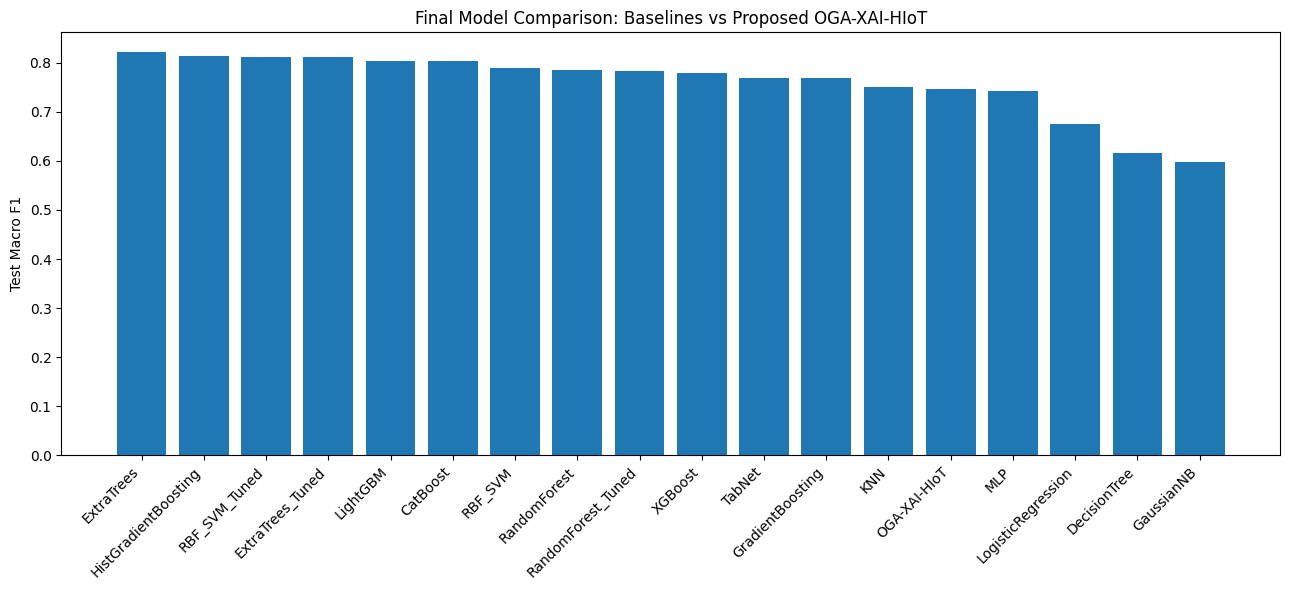

Best model by clean test macro F1: ExtraTrees
No clean 99%+ accuracy observed. Do not force 99%; report valid macro F1 and ordinal metrics.


In [ ]:
# ============================================================
# 16. Model comparison: baselines + proposed model
# ============================================================
all_results_parts = [baseline_results]
if 'tuned_results' in globals() and not tuned_results.empty:
    all_results_parts.append(tuned_results)
if 'advanced_results' in globals() and not advanced_results.empty:
    # align column names for display where possible
    adv = advanced_results.copy()
    all_results_parts.append(adv)
all_results_parts.append(oga_result)

# Normalize display columns
comparison_rows = []
for df_res in all_results_parts:
    for _, r in df_res.iterrows():
        row = {
            "Model": r.get("Model", "Unknown"),
            "Test_Accuracy": r.get("Test_Accuracy", np.nan),
            "Test_Balanced_Accuracy": r.get("Test_Balanced_Accuracy", np.nan),
            "Test_Macro_Precision": r.get("Test_Macro_Precision", np.nan),
            "Test_Macro_Recall": r.get("Test_Macro_Recall", np.nan),
            "Test_Macro_F1": r.get("Test_Macro_F1", np.nan),
            "Test_Weighted_F1": r.get("Test_Weighted_F1", np.nan),
            "Test_MCC": r.get("Test_MCC", np.nan),
            "Test_Cohen_Kappa": r.get("Test_Cohen_Kappa", np.nan),
            "Test_Mean_Absolute_Ordinal_Error": r.get("Test_Mean_Absolute_Ordinal_Error", np.nan),
            "Test_Severe_Misclassification_Rate": r.get("Test_Severe_Misclassification_Rate", np.nan),
            "Test_Multiclass_ROC_AUC_OVR": r.get("Test_Multiclass_ROC_AUC_OVR", np.nan),
        }
        comparison_rows.append(row)

model_comparison = pd.DataFrame(comparison_rows).drop_duplicates(subset=["Model"], keep="last")
model_comparison = model_comparison.sort_values("Test_Macro_F1", ascending=False)
save_csv(model_comparison, "07_model_performance_comparison.csv")
display(model_comparison)

plt.figure(figsize=(13, 6))
plt.bar(model_comparison["Model"], model_comparison["Test_Macro_F1"])
plt.ylabel("Test Macro F1")
plt.title("Final Model Comparison: Baselines vs Proposed OGA-XAI-HIoT")
plt.xticks(rotation=45, ha="right")
save_fig("Figure_6_Final_Model_Performance_Comparison.png")

best_overall_name = model_comparison.iloc[0]["Model"]
print("Best model by clean test macro F1:", best_overall_name)

if model_comparison["Test_Accuracy"].max() >= 0.99:
    print("⚠ 99%+ accuracy found. Run leakage audit carefully before reporting.")
else:
    print("No clean 99%+ accuracy observed. Do not force 99%; report valid macro F1 and ordinal metrics.")

Saved: /content/OGA_XAI_HIoT_outputs/tables/10_attention_group_importance.csv


,Group,Mean_Cross_Group_Attention
0,Physiological,0.458650
2,IoT_Data_Quality,0.205432
1,Behavioral,0.201399
3,Network_Cloud,0.071692
4,Alert,0.062827


Saved figure: /content/OGA_XAI_HIoT_outputs/figures/Figure_12_Attention_Group_Importance.png


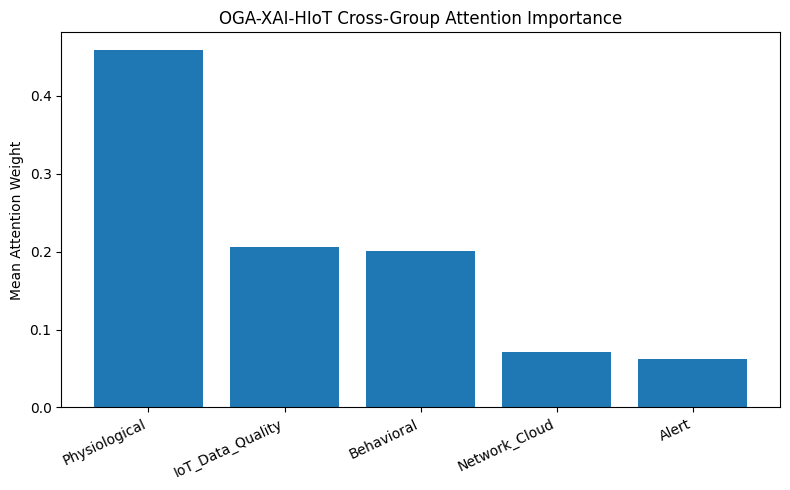

Saved: /content/OGA_XAI_HIoT_outputs/tables/09_group_ablation_analysis.csv


,Removed_or_Occluded_Group,Base_Macro_F1,Occluded_Macro_F1,Macro_F1_Drop,Features
0,Physiological,0.747152,0.355848,0.391304,"Heart_Rate, Blood_Pressure, Blood_Oxygen_Level..."
2,IoT_Data_Quality,0.747152,0.668455,0.078696,"IoT_Device_Connectivity, EHR_Data_Completeness..."
1,Behavioral,0.747152,0.701736,0.045416,"Activity_Level, Sleep_Duration_Hours, Stress_I..."
3,Network_Cloud,0.747152,0.740019,0.007132,"Healthcare_Network_Latency_ms, Cloud_Data_Tran..."
4,Alert,0.747152,0.746030,0.001122,Medical_Alert_Frequency


Saved figure: /content/OGA_XAI_HIoT_outputs/figures/Figure_11_Group_Ablation_Analysis.png


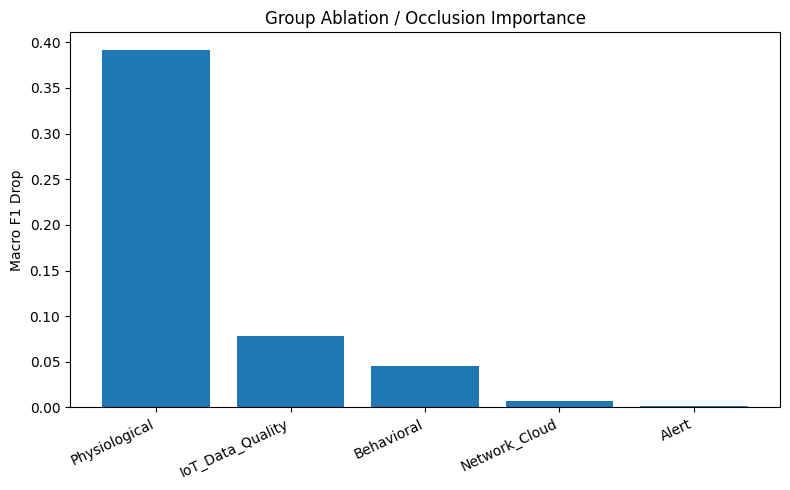

Saved: /content/OGA_XAI_HIoT_outputs/tables/08_global_feature_importance_OGA_permutation.csv


,Feature,Importance_Mean_F1_Drop,Importance_Std
11,EHR_Data_Completeness,0.076591,0.007265
1,Blood_Pressure,0.075492,0.004407
3,Body_Temperature,0.062569,0.002438
2,Blood_Oxygen_Level,0.061147,0.003981
5,Glucose_Level,0.056356,0.007023
6,ECG_Signal_Intensity,0.055058,0.006173
20,ECG_HR_Interaction,0.052600,0.002527
19,Glucose_Stress_Interaction,0.047121,0.011897
0,Heart_Rate,0.043118,0.006341
21,Activity_Sleep_Ratio,0.041668,0.004935


Saved figure: /content/OGA_XAI_HIoT_outputs/figures/Figure_10_OGA_Permutation_Feature_Importance.png


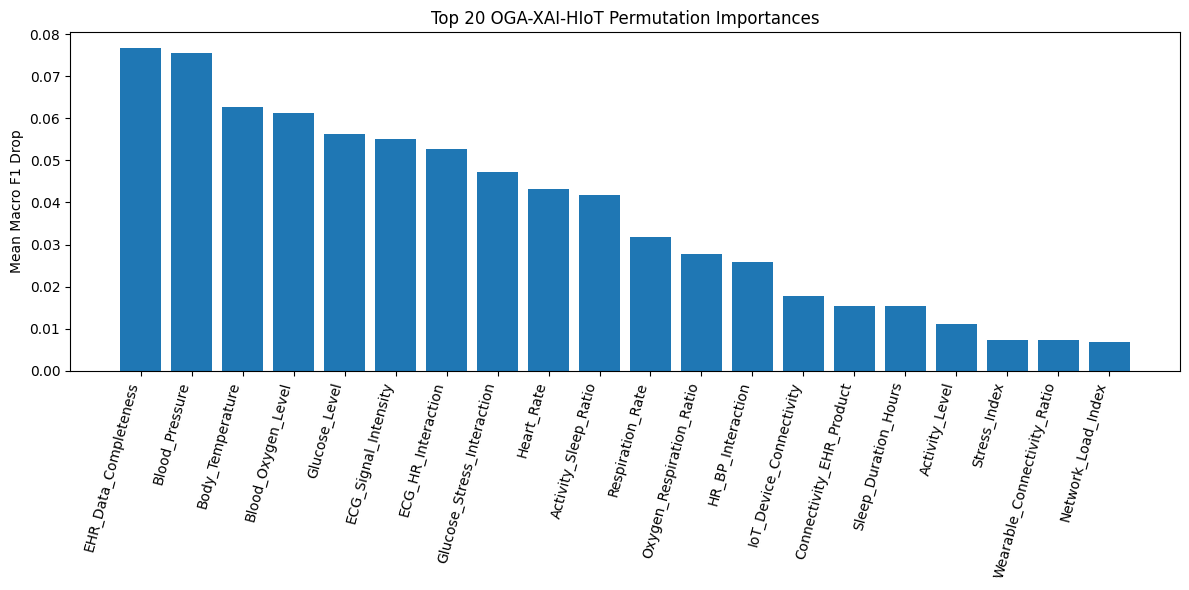

PosixPath('/content/OGA_XAI_HIoT_outputs/figures/Figure_10_OGA_Permutation_Feature_Importance.png')

In [ ]:
# ============================================================
# 17. Explainability: attention, group ablation, permutation importance
# ============================================================
# 17.1 Attention-based group importance from OGA-XAI-HIoT
attn_mean = oga_test_attention.mean(axis=0)
attn_df = pd.DataFrame({"Group": oga_model.group_names, "Mean_Cross_Group_Attention": attn_mean})
attn_df = attn_df.sort_values("Mean_Cross_Group_Attention", ascending=False)
save_csv(attn_df, "10_attention_group_importance.csv")
display(attn_df)

plt.figure(figsize=(8, 5))
plt.bar(attn_df["Group"], attn_df["Mean_Cross_Group_Attention"])
plt.ylabel("Mean Attention Weight")
plt.title("OGA-XAI-HIoT Cross-Group Attention Importance")
plt.xticks(rotation=25, ha="right")
save_fig("Figure_12_Attention_Group_Importance.png")

# 17.2 Group occlusion ablation on OGA. Values are set to 0 after scaling, representing training mean.
base_f1 = f1_score(y_test, oga_test_pred, average="macro", zero_division=0)
ablation_rows = []
for group, idx in GROUP_INDICES.items():
    X_occ = X_test_scaled.copy()
    group_cols = [FEATURE_NAMES[i] for i in idx]
    X_occ[group_cols] = 0.0
    pred_occ, proba_occ, _ = predict_torch_model(oga_model, X_occ)
    f1_occ = f1_score(y_test, pred_occ, average="macro", zero_division=0)
    ablation_rows.append({
        "Removed_or_Occluded_Group": group,
        "Base_Macro_F1": base_f1,
        "Occluded_Macro_F1": f1_occ,
        "Macro_F1_Drop": base_f1 - f1_occ,
        "Features": ", ".join(group_cols)
    })

ablation_df = pd.DataFrame(ablation_rows).sort_values("Macro_F1_Drop", ascending=False)
save_csv(ablation_df, "09_group_ablation_analysis.csv")
display(ablation_df)

plt.figure(figsize=(8, 5))
plt.bar(ablation_df["Removed_or_Occluded_Group"], ablation_df["Macro_F1_Drop"])
plt.ylabel("Macro F1 Drop")
plt.title("Group Ablation / Occlusion Importance")
plt.xticks(rotation=25, ha="right")
save_fig("Figure_11_Group_Ablation_Analysis.png")

# 17.3 Model-agnostic permutation importance for OGA on test set
# This is slower but directly supports RQ1.
def oga_macro_f1_score(X_df, y_true):
    pred, _, _ = predict_torch_model(oga_model, X_df)
    return f1_score(y_true, pred, average="macro", zero_division=0)

rng = np.random.default_rng(SEED)
perm_rows = []
base_score = oga_macro_f1_score(X_test_scaled, y_test)
for feature in FEATURE_NAMES:
    drops = []
    for repeat in range(5):
        X_perm = X_test_scaled.copy()
        X_perm[feature] = rng.permutation(X_perm[feature].values)
        score = oga_macro_f1_score(X_perm, y_test)
        drops.append(base_score - score)
    perm_rows.append({"Feature": feature, "Importance_Mean_F1_Drop": np.mean(drops), "Importance_Std": np.std(drops)})

oga_perm = pd.DataFrame(perm_rows).sort_values("Importance_Mean_F1_Drop", ascending=False)
save_csv(oga_perm, "08_global_feature_importance_OGA_permutation.csv")
display(oga_perm.head(20))

plt.figure(figsize=(12, 6))
top_perm = oga_perm.head(20)
plt.bar(top_perm["Feature"], top_perm["Importance_Mean_F1_Drop"])
plt.ylabel("Mean Macro F1 Drop")
plt.title("Top 20 OGA-XAI-HIoT Permutation Importances")
plt.xticks(rotation=75, ha="right")
save_fig("Figure_10_OGA_Permutation_Feature_Importance.png")

Running SHAP for: ExtraTrees


PermutationExplainer explainer: 301it [15:33,  3.14s/it]

Saved: /content/OGA_XAI_HIoT_outputs/tables/08b_SHAP_global_feature_importance_best_tree.csv


,Feature,Mean_Abs_SHAP
11,EHR_Data_Completeness,0.037603
1,Blood_Pressure,0.031393
2,Blood_Oxygen_Level,0.029551
5,Glucose_Level,0.022752
6,ECG_Signal_Intensity,0.022189
10,IoT_Device_Connectivity,0.018709
19,Glucose_Stress_Interaction,0.018535
0,Heart_Rate,0.017226
20,ECG_HR_Interaction,0.017075
18,Oxygen_Respiration_Ratio,0.017049


Saved figure: /content/OGA_XAI_HIoT_outputs/figures/Figure_10_SHAP_Feature_Importance.png


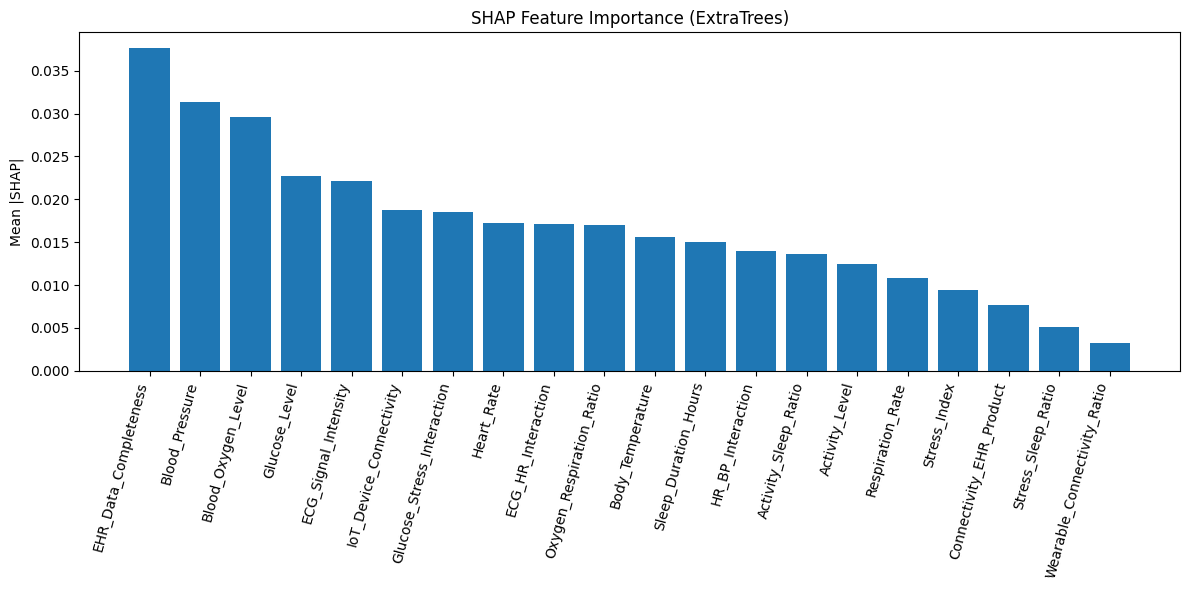

In [ ]:
# ============================================================
# 18. SHAP explainability for best tree-based baseline where possible
# ============================================================
# SHAP is optional and may take time. Permutation importance and OGA attention/ablation already provide required explanations.

if RUN_SHAP and HAS_SHAP:
    try:
        import shap
        # Prefer a tree model for SHAP if available.
        shap_model_name = None
        for candidate in ["ExtraTrees_Tuned", "ExtraTrees", "RandomForest_Tuned", "RandomForest", "XGBoost", "LightGBM", "CatBoost"]:
            if candidate in fitted_models:
                shap_model_name = candidate
                break
        if shap_model_name is None:
            raise RuntimeError("No suitable tree-based model available for SHAP.")
        shap_model = fitted_models[shap_model_name]
        print("Running SHAP for:", shap_model_name)
        sample_X = X_test_scaled.sample(n=min(300, len(X_test_scaled)), random_state=SEED)
        explainer = shap.Explainer(shap_model.predict_proba, X_train_scaled.sample(n=min(300, len(X_train_scaled)), random_state=SEED))
        shap_values = explainer(sample_X)
        # For multiclass, shap_values.values may be [samples, features, classes]
        vals = shap_values.values
        if vals.ndim == 3:
            mean_abs = np.abs(vals).mean(axis=(0, 2))
        else:
            mean_abs = np.abs(vals).mean(axis=0)
        shap_importance = pd.DataFrame({"Feature": sample_X.columns, "Mean_Abs_SHAP": mean_abs}).sort_values("Mean_Abs_SHAP", ascending=False)
        save_csv(shap_importance, "08b_SHAP_global_feature_importance_best_tree.csv")
        display(shap_importance.head(20))
        plt.figure(figsize=(12, 6))
        top_shap = shap_importance.head(20)
        plt.bar(top_shap["Feature"], top_shap["Mean_Abs_SHAP"])
        plt.ylabel("Mean |SHAP|")
        plt.title(f"SHAP Feature Importance ({shap_model_name})")
        plt.xticks(rotation=75, ha="right")
        save_fig("Figure_10_SHAP_Feature_Importance.png")
    except Exception as e:
        print("⚠ SHAP skipped/failed:", e)
else:
    print("SHAP skipped by configuration or unavailable.")

In [ ]:
# ============================================================
# 19. Local explanation cases
# ============================================================


local_cases = []
for class_id, class_name in enumerate(CLASS_NAMES):
    mask = (pred_df["True_ID"] == class_id) & (pred_df["Predicted_ID"] == class_id)
    if mask.any():
        row = pred_df[mask].iloc[0].to_dict()
        row["Case_Type"] = f"Correct_{class_name}"
        local_cases.append(row)

mis_mask = pred_df["True_ID"] != pred_df["Predicted_ID"]
if mis_mask.any():
    row = pred_df[mis_mask].iloc[0].to_dict()
    row["Case_Type"] = "Misclassified_Case"
    local_cases.append(row)

local_cases_df = pd.DataFrame(local_cases)
save_csv(local_cases_df, "11_local_explanation_cases.csv")
display(local_cases_df)

print("For manuscript writing, explain these cases using predicted probabilities, top permutation-important features, and group-attention weights.")

Saved: /content/OGA_XAI_HIoT_outputs/tables/11_local_explanation_cases.csv


,True_ID,True_Label,Predicted_ID,Predicted_Label,Prob_Stable,Prob_Moderate_Risk,Prob_High_Risk,Prob_Critical,Ordinal_Error,Case_Type
0,0,Stable,0,Stable,0.942108,0.044010,0.008676,0.005206,0,Correct_Stable
1,1,Moderate_Risk,1,Moderate_Risk,0.253287,0.618515,0.038071,0.090128,0,Correct_Moderate_Risk
2,2,High_Risk,2,High_Risk,0.014980,0.021635,0.940002,0.023383,0,Correct_High_Risk
3,3,Critical,3,Critical,0.015387,0.012622,0.010777,0.961213,0,Correct_Critical
4,3,Critical,2,High_Risk,0.041025,0.076978,0.557250,0.324747,1,Misclassified_Case


For manuscript writing, explain these cases using predicted probabilities, top permutation-important features, and group-attention weights.


In [ ]:
# ============================================================
# 20. Label separability and 99% validity audit
# ============================================================

# 20.1 Duplicate check across features + target
full_duplicate_count = df_fe.duplicated().sum()
feature_duplicate_count = df_fe[input_features].duplicated().sum()

# 20.2 Train-vs-test exact feature row overlap after split
train_feature_tuples = set(map(tuple, np.round(X_train_scaled.values, 8)))
test_feature_tuples = set(map(tuple, np.round(X_test_scaled.values, 8)))
overlap_count = len(train_feature_tuples.intersection(test_feature_tuples))

# 20.3 Perfect-score warning from models
max_test_acc = model_comparison["Test_Accuracy"].max()
max_test_f1 = model_comparison["Test_Macro_F1"].max()

validity_audit = pd.DataFrame([
    {"Audit_Item": "Full duplicate rows", "Value": full_duplicate_count, "Interpretation": "Should be 0 or handled before split"},
    {"Audit_Item": "Duplicate feature rows", "Value": feature_duplicate_count, "Interpretation": "High values may inflate performance if same features map to same label"},
    {"Audit_Item": "Train-test exact feature overlap", "Value": overlap_count, "Interpretation": "Should be 0 for strict testing"},
    {"Audit_Item": "Best clean test accuracy", "Value": max_test_acc, "Interpretation": "99%+ requires manual leakage review"},
    {"Audit_Item": "Best clean test macro F1", "Value": max_test_f1, "Interpretation": "Primary scientific score for this study"},
])
save_csv(validity_audit, "16_label_separability_and_99pct_validity_audit.csv")
display(validity_audit)

if max_test_acc >= 0.99:
    print("⚠ A 99%+ result was observed. Before claiming it, inspect leakage, duplicates, splits, and target-derived features.")
else:
    print("✓ No valid 99%+ test result observed. Report the clean best result and explain that 99% is not supported without leakage.")

Saved: /content/OGA_XAI_HIoT_outputs/tables/16_label_separability_and_99pct_validity_audit.csv


,Audit_Item,Value,Interpretation
0,Full duplicate rows,0.000000,Should be 0 or handled before split
1,Duplicate feature rows,0.000000,High values may inflate performance if same fe...
2,Train-test exact feature overlap,0.000000,Should be 0 for strict testing
3,Best clean test accuracy,0.821250,99%+ requires manual leakage review
4,Best clean test macro F1,0.821074,Primary scientific score for this study


✓ No valid 99%+ test result observed. Report the clean best result and explain that 99% is not supported without leakage.


In [ ]:
# ============================================================
# 21. Optional secondary dataset analyses for remaining RQs
# ============================================================
# RQ7 sensor battery consumption requires healthcare_iot_target_dataset.csv.
# Time-based fluctuation requires Multi-Sensor_Medical_IoT_Dataset.csv.
# These are not part of the primary model.

SECONDARY_BATTERY_CANDIDATES = [
    "/content/1.healthcare_iot_target_dataset.csv",
    "/content/1.healthcare_iot_target_dataset(1).csv",
    "/mnt/data/1.healthcare_iot_target_dataset.csv",
    "/mnt/data/1.healthcare_iot_target_dataset(1).csv",
]
SECONDARY_TIME_CANDIDATES = [
    "/content/4. Multi-Sensor_Medical_IoT_Dataset.csv",
    "/content/Multi-Sensor_Medical_IoT_Dataset.csv",
    "/mnt/data/4. Multi-Sensor_Medical_IoT_Dataset.csv",
    "/mnt/data/Multi-Sensor_Medical_IoT_Dataset.csv",
]

def maybe_find(candidates):
    for p in candidates:
        if Path(p).exists():
            return Path(p)
    return None

battery_path = maybe_find(SECONDARY_BATTERY_CANDIDATES)
if battery_path is not None:
    print("Battery/sensor dataset found:", battery_path)
    df_batt = pd.read_csv(battery_path)
    required_batt = ["Sensor_Type", "Battery_Level (%)", "Device_Battery_Level (%)"]
    if all(c in df_batt.columns for c in required_batt):
        batt_summary = df_batt.groupby("Sensor_Type").agg(
            Count=("Sensor_Type", "size"),
            Mean_Battery=("Battery_Level (%)", "mean"),
            Std_Battery=("Battery_Level (%)", "std"),
            Min_Battery=("Battery_Level (%)", "min"),
            Mean_Device_Battery=("Device_Battery_Level (%)", "mean"),
            Min_Device_Battery=("Device_Battery_Level (%)", "min"),
        ).reset_index()
        batt_summary["Low_Battery_Percent"] = df_batt.groupby("Sensor_Type")["Battery_Level (%)"].apply(lambda s: (s < 85).mean() * 100).values
        save_csv(batt_summary, "RQ7_sensor_battery_analysis.csv")
        display(batt_summary)
    else:
        print("Battery dataset found but required columns are missing:", required_batt)
else:
    pd.DataFrame([{"RQ": "RQ7", "Status": "Secondary battery/sensor dataset not found in this runtime."}]).to_csv(TABLE_DIR / "RQ7_sensor_battery_analysis_NOT_AVAILABLE.csv", index=False)
    print("RQ7 secondary battery/sensor dataset not found. Upload it to answer RQ7 empirically.")

time_path = maybe_find(SECONDARY_TIME_CANDIDATES)
if time_path is not None:
    print("Multi-sensor timestamp dataset found:", time_path)
    df_time = pd.read_csv(time_path)
    if "timestamp" in df_time.columns:
        df_time["timestamp"] = pd.to_datetime(df_time["timestamp"], errors="coerce")
        num_time_cols = df_time.select_dtypes(include=[np.number]).columns.tolist()
        time_rows = []
        for col in num_time_cols:
            s = df_time[col]
            mean = s.mean()
            std = s.std()
            cv = std / mean if abs(mean) > EPS else np.nan
            time_rows.append({"Feature": col, "Mean": mean, "Std": std, "Coefficient_of_Variation": cv})
        time_fluct = pd.DataFrame(time_rows).sort_values("Coefficient_of_Variation", ascending=False)
        save_csv(time_fluct, "RQ4_secondary_time_fluctuation_analysis.csv")
        display(time_fluct.head(20))
    else:
        print("Timestamp column not found in secondary time dataset.")
else:
    pd.DataFrame([{"RQ": "RQ4", "Status": "Secondary timestamp dataset not found in this runtime."}]).to_csv(TABLE_DIR / "RQ4_time_fluctuation_secondary_NOT_AVAILABLE.csv", index=False)
    print("RQ4 secondary timestamp dataset not found. Upload it to answer true time-based fluctuation empirically.")

RQ7 secondary battery/sensor dataset not found. Upload it to answer RQ7 empirically.
RQ4 secondary timestamp dataset not found. Upload it to answer true time-based fluctuation empirically.


In [ ]:
# ============================================================
# 22. RQ-wise summary table
# ============================================================
rq_rows = [
    {
        "RQ": "RQ1",
        "Question": "Which physiological, behavioral, and IoT-system factors have the strongest impact on patient health-status classification?",
        "Primary_Analysis": "OGA permutation importance, SHAP if available, group attention, group ablation",
        "Main_Output": "08_global_feature_importance_OGA_permutation.csv; 09_group_ablation_analysis.csv; 10_attention_group_importance.csv",
        "Caution": "Predictive importance, not clinical causality."
    },
    {
        "RQ": "RQ2",
        "Question": "Which activity patterns are associated with healthier or riskier patient conditions?",
        "Primary_Analysis": "Activity_Level, Daily_Steps, Sleep_Duration_Hours, Stress_Index grouped by health status",
        "Main_Output": "04_activity_health_profile.csv",
        "Caution": "Association within dataset only."
    },
    {
        "RQ": "RQ3",
        "Question": "Are any monitoring factors consistently high, low, or variable?",
        "Primary_Analysis": "Descriptive statistics, coefficient of variation, outlier percentage",
        "Main_Output": "03_high_low_consistency_analysis.csv",
        "Caution": "High/low interpretation depends on feature scale."
    },
    {
        "RQ": "RQ4",
        "Question": "Which physiological or sensor-based factors fluctuate most over time?",
        "Primary_Analysis": "Primary dataset has no timestamp; use coefficient of variation as variability proxy. Use secondary timestamp dataset for true time fluctuation.",
        "Main_Output": "03_high_low_consistency_analysis.csv; RQ4_secondary_time_fluctuation_analysis.csv if available",
        "Caution": "Do not call primary variability true time fluctuation."
    },
    {
        "RQ": "RQ5",
        "Question": "How do IoT-system variables affect healthcare monitoring outcomes?",
        "Primary_Analysis": "IoT connectivity, EHR completeness, wearable count, network latency, cloud transfer, alerts by health class",
        "Main_Output": "05_iot_network_status_summary.csv; group importance outputs",
        "Caution": "Outcome association and model contribution, not causal effect."
    },
    {
        "RQ": "RQ6",
        "Question": "Is there evidence of significant delay in healthcare IoT monitoring?",
        "Primary_Analysis": "Network latency and cloud transfer rate as proxy indicators",
        "Main_Output": "05_iot_network_status_summary.csv",
        "Caution": "No direct collection-to-transmission timestamps in primary dataset."
    },
    {
        "RQ": "RQ7",
        "Question": "Which type of sensor consumes more battery power?",
        "Primary_Analysis": "Requires secondary healthcare_iot_target_dataset.csv",
        "Main_Output": "RQ7_sensor_battery_analysis.csv if available",
        "Caution": "Battery level association is not the same as true power consumption unless discharge rate is known."
    },
    {
        "RQ": "RQ8",
        "Question": "Which ML model provides the best baseline performance?",
        "Primary_Analysis": "Clean train/validation/test comparison across baselines and OGA-XAI-HIoT",
        "Main_Output": "07_model_performance_comparison.csv",
        "Caution": "Select by macro F1 and clinical-risk recall, not accuracy only."
    },
    {
        "RQ": "RQ9",
        "Question": "What comfort, compatibility, power-source, and deployment challenges remain?",
        "Primary_Analysis": "Literature-based discussion",
        "Main_Output": "Discussion section, not dataset-derived table",
        "Caution": "Do not claim patient comfort or rural power feasibility from primary dataset."
    },
]
rq_summary = pd.DataFrame(rq_rows)
save_csv(rq_summary, "15_RQ_wise_summary.csv")
display(rq_summary)

Saved: /content/OGA_XAI_HIoT_outputs/tables/15_RQ_wise_summary.csv


,RQ,Question,Primary_Analysis,Main_Output,Caution
0,RQ1,"Which physiological, behavioral, and IoT-syste...","OGA permutation importance, SHAP if available,...",08_global_feature_importance_OGA_permutation.c...,"Predictive importance, not clinical causality."
1,RQ2,Which activity patterns are associated with he...,"Activity_Level, Daily_Steps, Sleep_Duration_Ho...",04_activity_health_profile.csv,Association within dataset only.
2,RQ3,"Are any monitoring factors consistently high, ...","Descriptive statistics, coefficient of variati...",03_high_low_consistency_analysis.csv,High/low interpretation depends on feature scale.
3,RQ4,Which physiological or sensor-based factors fl...,Primary dataset has no timestamp; use coeffici...,03_high_low_consistency_analysis.csv; RQ4_seco...,Do not call primary variability true time fluc...
4,RQ5,How do IoT-system variables affect healthcare ...,"IoT connectivity, EHR completeness, wearable c...",05_iot_network_status_summary.csv; group impor...,"Outcome association and model contribution, no..."
5,RQ6,Is there evidence of significant delay in heal...,Network latency and cloud transfer rate as pro...,05_iot_network_status_summary.csv,No direct collection-to-transmission timestamp...
6,RQ7,Which type of sensor consumes more battery power?,Requires secondary healthcare_iot_target_datas...,RQ7_sensor_battery_analysis.csv if available,Battery level association is not the same as t...
7,RQ8,Which ML model provides the best baseline perf...,Clean train/validation/test comparison across ...,07_model_performance_comparison.csv,"Select by macro F1 and clinical-risk recall, n..."
8,RQ9,"What comfort, compatibility, power-source, and...",Literature-based discussion,"Discussion section, not dataset-derived table",Do not claim patient comfort or rural power fe...


In [ ]:
# ============================================================
# 23. Final export package
# ============================================================
# This cell creates a ZIP file containing all output tables and figures.

import zipfile
zip_path = OUTPUT_DIR.parent / "OGA_XAI_HIoT_Final_Outputs.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for file_path in OUTPUT_DIR.rglob("*"):
        if file_path.is_file():
            zf.write(file_path, arcname=file_path.relative_to(OUTPUT_DIR))

print("All outputs are stored in:", OUTPUT_DIR)
print("ZIP package created:", zip_path)

print("=" * 80)
print("FINAL SCIENTIFIC REPORTING NOTE")
print("=" * 80)


All outputs are stored in: /content/OGA_XAI_HIoT_outputs
ZIP package created: /content/OGA_XAI_HIoT_Final_Outputs.zip
FINAL SCIENTIFIC REPORTING NOTE
